In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
# import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing 
# from category_encoders import *
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, precision_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn import datasets, linear_model, metrics
from sklearn.metrics import  confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings("ignore")

### load data

In [2]:
data = pd.read_csv("./RNA_seq.csv")
dataT=np.array(data)
data=dataT.T
co=data[0]
data1=np.delete(data,0,axis=0)
data=data1
datadf= pd.DataFrame(data=data[0:,0:],columns=co)
datadf.head()
data=datadf
data= data.replace("NOTLC",value=0)
data= data.replace("LC",value=1)
X_yuan=data.drop(['Group'],axis=1)
y_yuan=data['Group']

### pre-processing

In [3]:
df = data
df = df.dropna()
df = df.drop_duplicates()
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.1)  # contamination 为异常值比例
lof_predictions = lof.fit_predict(df)
# 将预测结果添加到 DataFrame 中
df['LOF_Predictions'] = lof_predictions
# 筛选出离群值（预测结果为 -1 的点）
outliers = df[df['LOF_Predictions'] == -1]
print("离群值：")
print(outliers)
# 删除离群值所在的行
df_cleaned = df[df['LOF_Predictions'] == 1]  # 保留正常值
df_cleaned = df_cleaned.drop(columns=['LOF_Predictions'])  # 删除辅助列
print("删除离群值后的数据：")
print(df_cleaned)
df = df_cleaned
X=df.drop(['Group'],axis=1)
y=df['Group']

离群值：
      Group ENSG00000000003.15 ENSG00000000005.6 ENSG00000000419.13  \
8         1               7472                 1               4818   
26        1                791                 0                881   
31        1               1339                 0               3032   
37        1               1097                 1               1486   
56        1               2020                 1               1419   
...     ...                ...               ...                ...   
1027      1              10623                 3               4224   
1044      1               9468                 1               2420   
1055      1               4513                 0               4348   
1076      1               8401                 2               4145   
1081      1               2065                 0               5496   

     ENSG00000000457.14 ENSG00000000460.17 ENSG00000000938.13  \
8                   720                931                385   
26          

In [4]:
column=X.columns
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_pre=sc.fit_transform(X)
X_pre=pd.DataFrame(data=X_pre,columns=column)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X_pre,y,test_size=0.2,random_state=42,stratify=None)
print(f'Train shape : {X_train.shape}\nTest shape: {X_test.shape}')

Train shape : (790, 60660)
Test shape: (198, 60660)


### define function

In [5]:
def crosspredict(estimator,Xtrain,ytrain,cv):
    print("cross-validate across the entire data set")
    y_pred_cross=cross_val_predict(estimator,Xtrain,ytrain,cv=cv)
    confusion_cross=confusion_matrix(ytrain,y_pred_cross)
    a=accuracy_score(ytrain,y_pred_cross)
    p=precision_score(ytrain, y_pred_cross)
    r=recall_score(ytrain, y_pred_cross)
    f1=f1_score(ytrain, y_pred_cross)
    wf1=f1_score(ytrain, y_pred_cross, average='weighted')
    print('the confusion_matrix of the model is : \n',confusion_cross)
    print('the accuracy of the model is : ',a)
    print("the precision score of the model is : ", p)
    print("the recall score of the model is :", r)
    print('the f1_score of the model  is :',f1)
    print('the weighted_f1 of the model is :',wf1)
    print('the classification_report is :\n',classification_report(ytrain, y_pred_cross,digits=4))
    return a,p,r,f1,wf1,y_pred_cross,ytrain

def crosspredict_proba(estimator,Xtrain,ytrain,cv):
    print("cross-validate across the entire data set")
    y_pred_proba=cross_val_predict(estimator,Xtrain,ytrain,cv=cv,method='predict_proba')
    return y_pred_proba 

from imblearn.over_sampling import SMOTE


### define model

In [5]:
yuanc1=SVC(kernel="poly",degree=3,coef0=1,probability=True)
yuanc2=KNeighborsClassifier(n_neighbors=5)
yuanc3=LogisticRegression(C=0.5)
yuanc4= GaussianNB()
yuanc6=DecisionTreeClassifier(max_depth=8, min_samples_leaf=1, min_samples_split=6)
yuanc7=RandomForestClassifier(max_depth=4,n_estimators=108,n_jobs=-1,random_state=90)
yuanc8=AdaBoostClassifier(learning_rate=1,n_estimators=50)
yuanc9=GradientBoostingClassifier(learning_rate=0.01,loss='exponential',n_estimators=300)
yuanc10=XGBClassifier(booster='gbtree',learning_rate=0.01,n_estimators=400)
yuanc11=lgb.LGBMClassifier(max_depth=6,n_estimators=200)

yuan1=SVC(probability=True)
yuan2=KNeighborsClassifier()
yuan3=LogisticRegression()
yuan4=GaussianNB()
yuan6=DecisionTreeClassifier()
yuan7=RandomForestClassifier()
yuan8=AdaBoostClassifier()
yuan9=GradientBoostingClassifier()
yuan10=XGBClassifier()
yuan11=lgb.LGBMClassifier()

from sklearn.base import ClassifierMixin
from sklearn.base import TransformerMixin, BaseEstimator
class MyEstimator(BaseEstimator, ClassifierMixin):
    def __init__(self, model, mask) -> None:
        super().__init__()
        self.mask = mask
        self.model = model
    
    def fit(self, X, y=None):
        self.model.fit(X[self.mask],y)
        self.classes_ = self.model.classes_
        return self

    def predict(self, X):
        return self.model.predict(X[self.mask])
    
    def predict_proba(self,X):
        return self.model.predict_proba(X[self.mask])

sel_mask=[
#SVC
['ENSG00000223982.3','ENSG00000002726.21','ENSG00000039068.19','ENSG00000106089.12','ENSG00000182685.7','ENSG00000154813.10','ENSG00000204305.14' ,'ENSG00000135604.10', 'ENSG00000004399.13','ENSG00000000003.15'],
#KNN
['ENSG00000223982.3', 'ENSG00000229693.2', 'ENSG00000091262.16','ENSG00000204305.14', 'ENSG00000004399.13', 'ENSG00000039068.19'],
#LR
['ENSG00000102547.19','ENSG00000135604.10','ENSG00000159352.16','ENSG00000224215.1','ENSG00000234481.2','ENSG00000252275.1','ENSG00000271555.1'],
#GNB
['ENSG00000000938.13', 'ENSG00000004399.13','ENSG00000166123.14', 'ENSG00000204305.14', 'ENSG00000211643.2','ENSG00000259884.1', 'ENSG00000279940.1'],
#DT
['ENSG00000003147.19','ENSG00000004455.17','ENSG00000006327.14','ENSG00000018510.17','ENSG00000067064.11','ENSG00000154813.10','ENSG00000204305.14','ENSG00000234425.1','ENSG00000262772.2','ENSG00000272477.1'],
#RF
['ENSG00000106089.12', 'ENSG00000204305.14', 'ENSG00000223982.3','ENSG00000229693.2'],
#Ada
['ENSG00000000005.6', 'ENSG00000002933.9','ENSG00000019144.19', 'ENSG00000070366.14','ENSG00000091262.16','ENSG00000106089.12','ENSG00000204305.14','ENSG00000233117.4'],
#gbdt
['ENSG00000000005.6','ENSG00000000971.16', 'ENSG00000001631.16','ENSG00000002587.10', 'ENSG00000004779.10','ENSG00000106089.12', 'ENSG00000144130.11', 'ENSG00000204305.14'],
#XGB
['ENSG00000008128.23','ENSG00000106089.12','ENSG00000170989.10','ENSG00000006327.14','ENSG00000018510.17','ENSG00000204305.14',],
#LGB
['ENSG00000106089.12', 'ENSG00000170989.10','ENSG00000204305.14'],
]

sel_seq_dt_mask=['ENSG00000003147.19','ENSG00000004455.17','ENSG00000006327.14','ENSG00000018510.17','ENSG00000067064.11','ENSG00000154813.10','ENSG00000204305.14','ENSG00000234425.1','ENSG00000262772.2','ENSG00000272477.1']
sel_seq_rf_mask=['ENSG00000106089.12', 'ENSG00000204305.14', 'ENSG00000223982.3','ENSG00000229693.2']
sel_seq_ada_mask=['ENSG00000000005.6', 'ENSG00000002933.9','ENSG00000019144.19', 'ENSG00000070366.14','ENSG00000091262.16','ENSG00000106089.12','ENSG00000204305.14','ENSG00000233117.4']
sel_seq_gb_mask=['ENSG00000000005.6','ENSG00000000971.16', 'ENSG00000001631.16','ENSG00000002587.10', 'ENSG00000004779.10','ENSG00000106089.12', 'ENSG00000144130.11', 'ENSG00000204305.14']
sel_seq_xgb_mask=['ENSG00000008128.23','ENSG00000106089.12','ENSG00000170989.10','ENSG00000006327.14','ENSG00000018510.17','ENSG00000204305.14',]
sel_seq_KN_mask=['ENSG00000223982.3', 'ENSG00000229693.2', 'ENSG00000091262.16','ENSG00000204305.14', 'ENSG00000004399.13', 'ENSG00000039068.19']
sel_seq_Lightgbm_mask=['ENSG00000106089.12', 'ENSG00000170989.10','ENSG00000204305.14']
sel_seq_SVC_mask=['ENSG00000223982.3','ENSG00000002726.21','ENSG00000039068.19','ENSG00000106089.12','ENSG00000182685.7','ENSG00000154813.10','ENSG00000204305.14' ,'ENSG00000135604.10', 'ENSG00000004399.13','ENSG00000000003.15']
sel_seq_GNB_mask=['ENSG00000000938.13', 'ENSG00000004399.13','ENSG00000166123.14', 'ENSG00000204305.14', 'ENSG00000211643.2','ENSG00000259884.1', 'ENSG00000279940.1']
sel_seq_lr_mask=['ENSG00000102547.19','ENSG00000135604.10','ENSG00000159352.16','ENSG00000224215.1','ENSG00000234481.2','ENSG00000252275.1','ENSG00000271555.1']


model_dt_fs = MyEstimator(DecisionTreeClassifier(max_depth=8,min_samples_leaf=1,min_samples_split=4), sel_seq_dt_mask)
model_rf_fs = MyEstimator(RandomForestClassifier(max_depth=4,n_estimators=108,n_jobs=-1,random_state=90), sel_seq_rf_mask)
model_ada_fs = MyEstimator(AdaBoostClassifier(learning_rate=1,n_estimators=50), sel_seq_ada_mask)
model_gb_fs = MyEstimator(GradientBoostingClassifier(learning_rate=0.01,loss='exponential',n_estimators=300), sel_seq_gb_mask)
model_xgb_fs = MyEstimator(XGBClassifier(booster='gbtree',learning_rate=0.01,max_depth=5,n_estimators=400), mask=sel_seq_xgb_mask)
model_KN_fs = MyEstimator(KNeighborsClassifier(n_neighbors=5), mask=sel_seq_KN_mask)
model_Lightgbm_fs = MyEstimator(lgb.LGBMClassifier(max_depth=6,n_estimators=200), mask=sel_seq_Lightgbm_mask)
model_SVC_fs = MyEstimator(SVC(kernel="poly",degree=3,coef0=1,probability=True),mask=sel_seq_SVC_mask)
model_GNB_fs = MyEstimator(GaussianNB(),mask=sel_seq_GNB_mask)
model_lr_fs = MyEstimator(LogisticRegression(C=0.5),mask=sel_seq_lr_mask)

from itertools import *

feature=list(set(sel_seq_dt_mask+sel_seq_rf_mask+sel_seq_ada_mask+sel_seq_xgb_mask+sel_seq_GNB_mask))

from sklearn.ensemble import VotingClassifier
model_voting_hard = VotingClassifier([  
    ("dt",model_dt_fs),
    ("rf",model_rf_fs ),
    ("ada", model_ada_fs),
    ("xgb", model_xgb_fs),
    ("GNB",model_GNB_fs),
], voting="hard")


from mlxtend.classifier import StackingClassifier
model_Stacking_cross = StackingClassifier(classifiers=[
    (model_dt_fs),
    (model_rf_fs ),
    (model_ada_fs),
    (model_xgb_fs),
    (model_GNB_fs),
],meta_classifier=LogisticRegression(C=10))



In [7]:
y=y.astype(int)

### calculate accuracy precision recall f1 and auc

In [7]:

from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df_acc = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_pre = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_rec = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_f1 = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_auc = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']) 

y = y.astype(int)
yuanname = ['SVC', 'KNN', 'LR', 'GNB', 'DT', 'RF', 'Ada', 'GBDT']
listname = ['SVC+', 'KNN+', 'LR+', 'GNB+', 'DT+', 'RF+', 'Ada+', 'GBDT+']

for j in range(8):
    print(yuanname[j])
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  
    skf = StratifiedKFold(n_splits=10)
    for train_index, test_index in skf.split(X_yuan, y_yuan):
        X_train, X_test = X_yuan.iloc[train_index], X_yuan.iloc[test_index]
        y_train, y_test = y_yuan.iloc[train_index], y_yuan.iloc[test_index]
        print("split over")
        X_train_resampled, y_train_resampled = smote_resample(X_train, y_train)
        print("resample over")
        modelyuan[j].fit(X_train_resampled, y_train_resampled)
        print("fit over")
        y_pred = modelyuan[j].predict(X_test)
        y_pred_proba = modelyuan[j].predict_proba(X_test)[:, 1] 

        fold_accuracies.append(accuracy_score(y_test, y_pred))
        fold_precisions.append(precision_score(y_test, y_pred))
        fold_recalls.append(recall_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred))
        fold_aucs.append(roc_auc_score(y_test, y_pred_proba))  


    df_acc = df_acc.append({'Model': yuanname[j], '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': yuanname[j], '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': yuanname[j], '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': yuanname[j], '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': yuanname[j], '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True) 

    
    print(listname[j])
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  
    skf = StratifiedKFold(n_splits=10)
    for train_index, test_index in skf.split(X_pre[sel_mask[j]], y):
        X_train, X_test = X_pre[sel_mask[j]].iloc[train_index], X_pre[sel_mask[j]].iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        print("split over")
        X_train_resampled, y_train_resampled = smote_resample(X_train, y_train)
        print("resample over")
        modelyuanc[j].fit(X_train_resampled, y_train_resampled)
        print("fit over")
        y_pred = modelyuanc[j].predict(X_test)
        y_pred_proba = modelyuanc[j].predict_proba(X_test)[:, 1]  

        fold_accuracies.append(accuracy_score(y_test, y_pred))
        fold_precisions.append(precision_score(y_test, y_pred))
        fold_recalls.append(recall_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred))
        fold_aucs.append(roc_auc_score(y_test, y_pred_proba))  
  

    df_acc = df_acc.append({'Model': listname[j], '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': listname[j], '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': listname[j], '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': listname[j], '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': listname[j], '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)  

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy import stats
from sklearn.model_selection import StratifiedKFold
def smote_resample(X_train, y_train):
    smote = SMOTE(random_state=100,k_neighbors=50)
    return smote.fit_resample(X_train, y_train)

yuanname1 = ['XGB', 'LGB']
listname1 = ['XGB+', 'LGB+']
modelyuan1 = [yuan10, yuan11]
modelyuanc1 = [yuanc10, yuanc11]
X_arr_yuan = np.array(X_yuan)

sel_mask_1=[
#XGB
['ENSG00000008128.23','ENSG00000106089.12','ENSG00000170989.10','ENSG00000006327.14','ENSG00000018510.17','ENSG00000204305.14',],
#LGB
['ENSG00000106089.12', 'ENSG00000170989.10','ENSG00000204305.14'],
]

for j in range(2):
    # 初始化一个列表来存储每一折的准确率、精确率、召回率、F1 和 AUC
    print(yuanname1[j])
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  # 新增 AUC 列表
    skf = StratifiedKFold(n_splits=10)
    for train_index, test_index in skf.split(X_arr_yuan, y_yuan):
        X_train, X_test = X_arr_yuan[train_index], X_arr_yuan[test_index]
        y_train, y_test = y_yuan.iloc[train_index], y_yuan.iloc[test_index]
        print("split over")
        X_train_resampled, y_train_resampled = smote_resample(X_train, y_train)
        print("resample over")
        modelyuan1[j].fit(X_train_resampled, y_train_resampled)
        print("fit over")
        y_pred = modelyuan1[j].predict(X_test)
        y_pred_proba = modelyuan1[j].predict_proba(X_test)[:, 1]  
        fold_accuracies.append(accuracy_score(y_test, y_pred))
        fold_precisions.append(precision_score(y_test, y_pred))
        fold_recalls.append(recall_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred))
        fold_aucs.append(roc_auc_score(y_test, y_pred_proba))  

    df_acc = df_acc.append({'Model': yuanname1[j], '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': yuanname1[j], '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': yuanname1[j], '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': yuanname1[j], '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': yuanname1[j], '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)  # 新增 AUC DataFrame


    X_pre_arr = np.array(X_pre[sel_mask_1[j]])
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  # 新增 AUC 列表
    print(listname1[j])
    skf = StratifiedKFold(n_splits=10)
    for train_index, test_index in skf.split(X_pre_arr, y):
        X_train, X_test = X_pre_arr[train_index], X_pre_arr[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        print("split over")
        X_train_resampled, y_train_resampled = smote_resample(X_train, y_train)
        print("resample over")
        modelyuanc1[j].fit(X_train_resampled, y_train_resampled)
        print("fit over")
        y_pred = modelyuanc1[j].predict(X_test)
        y_pred_proba = modelyuanc1[j].predict_proba(X_test)[:, 1] 
        fold_accuracies.append(accuracy_score(y_test, y_pred))
        fold_precisions.append(precision_score(y_test, y_pred))
        fold_recalls.append(recall_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred))
        fold_aucs.append(roc_auc_score(y_test, y_pred_proba))  


    df_acc = df_acc.append({'Model': listname1[j], '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': listname1[j], '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': listname1[j], '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': listname1[j], '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': listname1[j], '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)  

In [8]:
### early ensemble model

from sklearn.metrics import roc_auc_score

def smote_resample(X_train, y_train):
    smote = SMOTE(random_state=100,k_neighbors=50)
    return smote.fit_resample(X_train, y_train)
from scipy import stats
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score,accuracy_score
from sklearn.model_selection import StratifiedKFold

fold_accuracies = []
fold_precisions=[]
fold_recalls=[]
fold_f1s=[]
y_scores_early=[]
y_true_early=[]

X_new=X[['ENSG00000106089.12', 'ENSG00000204305.14', 'ENSG00000223982.3','ENSG00000229693.2']]
X_arr=np.array(X)

# 2) 创建类平衡的集成
n_ensembles = 10  # 集成数量
kf = StratifiedKFold(n_splits=n_ensembles)

# 3) 代价敏感分类器
# 定义代价矩阵
cost_matrix = np.array([[3, 1], [1,3]])

# 计算代价敏感权重
class_weights = {}
for i in range(len(np.unique(y))):
    class_weights[i] = cost_matrix[i, 1] / (cost_matrix[i, 1] + cost_matrix[i, 0])

# 4) 训练和评估模型
ensemble_results = []

# 在训练和评估模型的循环中添加 AUC 的计算
for train_index, test_index in kf.split(X_new, y):
    X_train, X_test = X_new.iloc[train_index], X_new.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # 随机森林分类器
    early = RandomForestClassifier(n_estimators=150, class_weight=class_weights, random_state=42)
    
    X_train_resampled, y_train_resampled = smote_resample(X_train, y_train)
    early.fit(X_train_resampled, y_train_resampled)
    
    # 预测测试集
    y_pred = early.predict(X_test)
    y_pred_proba = early.predict_proba(X_test)[:, 1]
    
    # 计算性能指标
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    # 计算 AUC
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # 计算代价
    cm = confusion_matrix(y_test, y_pred)
    cost = cm[0, 1] * cost_matrix[1, 0] + cm[1, 0] * cost_matrix[0, 1]
    total_samples = len(y_test)
    cost_sensitive_accuracy = 1 - (cost / total_samples)
    
    ensemble_results.append({
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Weighted_F1': weighted_f1,
        'Cost Sensitive Accuracy': cost_sensitive_accuracy,
        'AUC': auc  # 添加 AUC 到结果字典中
    })
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    
    y_scores_early.extend(y_pred_proba)
    y_true_early.extend(y_test)

# 打印每个集成的结果
for i, result in enumerate(ensemble_results):
    print(f"Ensemble {i+1} Results: {result}")

# 计算并打印所有集成的平均结果
average_results = {metric: np.mean([results[metric] for results in ensemble_results]) for metric in ensemble_results[0]}
print(f"Average Results: {average_results}")

# 计算整体的准确率、精确率、召回率、F1 和 AUC
overall_accuracy = average_results['Accuracy']
overall_precision = average_results['Precision']
overall_recall = average_results['Recall']
overall_f1 = average_results['F1 Score']
overall_auc = average_results['AUC']  # 添加 AUC 的整体结果

# 计算标准偏差
std_dev_acc = np.std(fold_accuracies)
std_dev_pre = np.std(fold_precisions)
std_dev_rec = np.std(fold_recalls)
std_dev_f1 = np.std(fold_f1s)

# 计算 AUC 的标准偏差
fold_aucs = [result['AUC'] for result in ensemble_results]
std_dev_auc = np.std(fold_aucs)

# 计算95%置信区间
confidence_interval_acc = stats.t.interval(0.95, len(fold_accuracies)-1, loc=np.mean(fold_accuracies), scale=stats.sem(fold_accuracies))
confidence_interval_pre = stats.t.interval(0.95, len(fold_precisions)-1, loc=np.mean(fold_precisions), scale=stats.sem(fold_precisions))
confidence_interval_rec = stats.t.interval(0.95, len(fold_recalls)-1, loc=np.mean(fold_recalls), scale=stats.sem(fold_recalls))
confidence_interval_f1 = stats.t.interval(0.95, len(fold_f1s)-1, loc=np.mean(fold_f1s), scale=stats.sem(fold_f1s))
confidence_interval_auc = stats.t.interval(0.95, len(fold_aucs)-1, loc=np.mean(fold_aucs), scale=stats.sem(fold_aucs))  # 添加 AUC 的置信区间

print("accuracy")
print("Fold accuracies:", fold_accuracies)
print("Overall accuracy:", overall_accuracy)
print("Standard deviation:", std_dev_acc)
print("95% confidence interval:", confidence_interval_acc)
print("precision")
print("Fold precisions:", fold_precisions)
print("Overall precision:", overall_precision)
print("Standard deviation:", std_dev_pre)
print("95% confidence interval:", confidence_interval_pre)
print("recall")
print("Fold recalls:", fold_recalls)
print("Overall recall:", overall_recall)
print("Standard deviation:", std_dev_rec)
print("95% confidence interval:", confidence_interval_rec)
print("f1")
print("Fold f1s:", fold_f1s)
print("Overall f1:", overall_f1)
print("Standard deviation:", std_dev_f1)
print("95% confidence interval:", confidence_interval_f1)
print("auc")
print("Fold AUCs:", fold_aucs)
print("Overall AUC:", overall_auc)
print("Standard deviation:", std_dev_auc)
print("95% confidence interval:", confidence_interval_auc)

Ensemble 1 Results: {'Accuracy': 0.98989898989899, 'Precision': 1.0, 'Recall': 0.9888888888888889, 'F1 Score': 0.9944134078212291, 'Weighted_F1': 0.9901365908422657, 'Cost Sensitive Accuracy': 0.98989898989899, 'AUC': 0.9987654320987653}
Ensemble 2 Results: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'Weighted_F1': 1.0, 'Cost Sensitive Accuracy': 1.0, 'AUC': 1.0}
Ensemble 3 Results: {'Accuracy': 0.98989898989899, 'Precision': 0.9888888888888889, 'Recall': 1.0, 'F1 Score': 0.9944134078212291, 'Weighted_F1': 0.9896613889557142, 'Cost Sensitive Accuracy': 0.98989898989899, 'AUC': 1.0}
Ensemble 4 Results: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'Weighted_F1': 1.0, 'Cost Sensitive Accuracy': 1.0, 'AUC': 1.0}
Ensemble 5 Results: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'Weighted_F1': 1.0, 'Cost Sensitive Accuracy': 1.0, 'AUC': 1.0}
Ensemble 6 Results: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 

In [71]:
df_acc=df_acc.append({'Model':"early", '1':0.98989898989899, '2':1.0,'3':0.98989898989899,'4':1.0,
                          '5':1.0,'6':1.0,'7':1.0,'8':0.98989898989899,
                          '9':0.9897959183673469,'10':0.9897959183673469},ignore_index=True)
df_pre=df_pre.append({'Model':"early", '1':1.0, '2':1.0,'3':0.9888888888888889,'4': 1.0,
                          '5': 1.0,'6': 1.0,'7': 1.0,'8': 1.0,
                          '9': 1.0,'10':0.9888888888888889},ignore_index=True)
df_rec=df_rec.append({'Model':"early", '1':0.9888888888888889, '2':1.0,'3':1.0,'4':1.0,
                          '5':1.0,'6':1.0,'7':1.0,'8':0.9887640449438202,
                          '9':0.9887640449438202,'10':1.0},ignore_index=True)
df_f1=df_f1.append({'Model':"early", '1':0.9944134078212291, '2':1.0,'3':0.9944134078212291,'4':1.0,
                          '5':1.0,'6':1.0,'7':1.0,'8':0.9943502824858756,
                          '9':0.9943502824858756,'10':0.9944134078212291},ignore_index=True)
df_auc=df_auc.append({'Model':"early", '1':0.9987654320987653, '2':1.0,'3':1.0,'4':1.0,
                          '5':1.0,'6':1.0,'7':1.0,'8':1.0,
                          '9':1.0,'10':0.9406991260923845},ignore_index=True)

In [ ]:
### deep model

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D, MaxPooling1D, Input, concatenate
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from tensorflow.keras.callbacks import ReduceLROnPlateau

accuracy_tr=[]
accuracy_te=[]
loss_tr=[]
loss_te=[]

scaler = StandardScaler()
X_deep = scaler.fit_transform(X)
lasso = Lasso(alpha=0.1)
lasso.fit(X_deep, y)
coefs = lasso.coef_
selected_features = X_deep[:, coefs != 0]
X_deep = selected_features
X_train, X_test, y_train, y_test = train_test_split(X_deep, y, test_size=0.2, random_state=84)
accuracy_scores_tt = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

train_loss=[]
val_loss=[]
train_accuracy=[]
val_accuracy=[]
y_true_test_deep=[]
y_pred_probs_deep=[]

train_acc1=[]
train_loss1=[]
test_acc1=[]
test_loss1=[]

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=84)

for train_idx, test_idx in kfold.split(X_deep, y):
    X_train = X_deep[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X_deep[test_idx]
    y_test = y.iloc[test_idx]

    models = []
    kk=5
    X_train = X_train.reshape((-1, X_train.shape[1], 1))
    X_test = X_test.reshape((-1, X_test.shape[1], 1))

    for i in range(kk):
        model = Sequential()
        model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
        model.add(MaxPooling1D(pool_size=2))
        model.add(Flatten())
        model.add(Dense(128, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
        models.append(model)

    first_layer_train = np.zeros((len(X_train), kk))
    first_layer_test = np.zeros((len(X_test), kk))

    for i, model in enumerate(models):
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.00008)
        
        model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

        history1=model.fit(X_train, y_train, epochs=500, batch_size=32, verbose=0)
        y_pred_train = model.predict(X_train).ravel()
        first_layer_train[:, i] = y_pred_train
        y_pred_test = model.predict(X_test).ravel()
        first_layer_test[:, i] = y_pred_test

    input_layer = Input(shape=(kk,))
    x = Dense(16, activation='relu')(input_layer)
    x=Dropout(0.5)(x)
    output_layer = Dense(1, activation='sigmoid')(x)
    nn_model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.000055)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
    nn_model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    history =nn_model.fit(first_layer_train, y_train, epochs=500, batch_size=16, verbose=0,validation_data=(first_layer_test, y_test)
                         )

    train_loss.append(history.history['loss'])
    val_loss.append(history.history['val_loss'])
    train_accuracy.append(history.history['accuracy'])
    val_accuracy.append(history.history['val_accuracy'])

    
    train_acc1.append(np.mean(train_accuracy))
    test_acc1.append(np.mean(val_accuracy))
    train_loss1.append(np.mean(train_loss))
    test_loss1.append(np.mean(val_loss))
    
    
    
    y_pred_tt=nn_model.predict(first_layer_train).ravel()
    y_pred_nn = nn_model.predict(first_layer_test).ravel()
    y_pred_probs_deep.extend(nn_model.predict(first_layer_test))
    y_true_test_deep.extend(y_test)

    y_pred_tt_binary=np.round(y_pred_tt)
    y_pred_nn_binary = np.round(y_pred_nn)
    accuracy_scores_tt.append(accuracy_score(y_train,y_pred_tt_binary))
    
    accuracy_scores.append(accuracy_score(y_test, y_pred_nn_binary))
    precision_scores.append(precision_score(y_test, y_pred_nn_binary))
    recall_scores.append(recall_score(y_test, y_pred_nn_binary))
    f1_scores.append(f1_score(y_test, y_pred_nn_binary))

fold_accuracies_tt=accuracy_scores_tt
fold_accuracies=accuracy_scores
fold_precisions=precision_scores
fold_recalls=recall_scores
fold_f1s=f1_scores

# 计算标准偏差
std_dev_acc = np.std(fold_accuracies)
std_dev_pre = np.std(fold_precisions)
std_dev_rec = np.std(fold_recalls)
std_dev_f1 = np.std(fold_f1s)

# 计算95%置信区间
confidence_interval_acc = stats.t.interval(0.95, len(fold_accuracies)-1, loc=np.mean(fold_accuracies), scale=stats.sem(fold_accuracies))
confidence_interval_pre = stats.t.interval(0.95, len(fold_precisions)-1, loc=np.mean(fold_precisions), scale=stats.sem(fold_precisions))
confidence_interval_rec = stats.t.interval(0.95, len(fold_recalls)-1, loc=np.mean(fold_recalls), scale=stats.sem(fold_recalls))
confidence_interval_f1 = stats.t.interval(0.95, len(fold_f1s)-1, loc=np.mean(fold_f1s), scale=stats.sem(fold_f1s))

overall_accuracy_tt=np.mean(fold_accuracies_tt)
overall_accuracy_deep=np.mean(fold_accuracies)
overall_precision_deep=np.mean(fold_precisions)
overall_recall_deep=np.mean(fold_recalls)
overall_f1_deep=np.mean(fold_f1s)

fpr_deep, tpr_deep, _ = roc_curve(y_true_test_deep, y_pred_probs_deep)
roc_auc_deep = auc(fpr_deep, tpr_deep)

print("accuracy")
print("Fold accuracies:", fold_accuracies)
print("Overall accuracy:", overall_accuracy_deep)
print("Standard deviation:", std_dev_acc)
print("95% confidence interval:", confidence_interval_acc)
print("precision")
print("Fold precisions:", fold_precisions)
print("Overall precision:", overall_precision_deep)
print("Standard deviation:", std_dev_pre)
print("95% confidence interval:", confidence_interval_pre)
print("recall")
print("Fold recalls:", fold_recalls)
print("Overall recall:", overall_recall_deep)
print("Standard deviation:", std_dev_rec)
print("95% confidence interval:", confidence_interval_rec)
print("f1")
print("Fold f1s:", fold_f1s)
print("Overall f1:", overall_f1_deep)
print("Standard deviation:", std_dev_f1)
print("95% confidence interval:", confidence_interval_f1)

mean_train_loss = np.mean(train_loss, axis=0)
mean_val_loss = np.mean(val_loss, axis=0)
std_train_loss = np.std(train_loss, axis=0)
std_val_loss = np.std(val_loss, axis=0)
mean_train_accuracy = np.mean(train_accuracy, axis=0)
mean_val_accuracy = np.mean(val_accuracy, axis=0)
std_train_accuracy= np.std(train_accuracy, axis=0)
std_val_accuracy = np.std(val_accuracy, axis=0)
epochs = range(1, max(len(mean_train_loss), len(mean_val_loss)) + 1)
plt.plot(epochs, mean_train_loss, 'y-',lw=2, label='Training loss')
plt.plot(epochs, mean_val_loss, 'g-', lw=2,label='Validation loss')
plt.plot(epochs, mean_train_accuracy, 'b-', lw=2,label='Training accuracy')
plt.plot(epochs, mean_val_accuracy, 'r-',lw=2, label='Validation accuracy')
plt.title('Training and Validation  ')
plt.xlabel('Epochs')
plt.ylabel('')
plt.legend()
plt.show()

# 绘制ROC曲线
plt.figure()
plt.plot(fpr_deep, tpr_deep, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc_deep)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [16]:
from sklearn.metrics import roc_curve, auc
import numpy as np


# 确定每份的大小
n = len(y_true_test_deep)
n_splits = 10
split_size = n // n_splits

# 计算每份的AUC值
auc_values = []
for i in range(n_splits):
    start_index = i * split_size
    end_index = (i + 1) * split_size if i < n_splits - 1 else n
    y_true_split = y_true_test_deep[start_index:end_index]
    y_pred_split = y_pred_probs_deep[start_index:end_index]
    
    # 计算ROC曲线
    fpr_split, tpr_split, _ = roc_curve(y_true_split, y_pred_split)
    # 计算AUC值
    auc_split = auc(fpr_split, tpr_split)
    auc_values.append(auc_split)

# 打印每份的AUC值
for i, auc in enumerate(auc_values):
    print(f"AUC for split {i+1}: {auc}")

AUC for split 1: 1.0
AUC for split 2: 1.0
AUC for split 3: 0.9954545454545455
AUC for split 4: 1.0
AUC for split 5: 1.0
AUC for split 6: 0.9962546816479401
AUC for split 7: 0.9977272727272728
AUC for split 8: 0.9965909090909091
AUC for split 9: 0.9079545454545455
AUC for split 10: 0.995418098510882


In [ ]:
df_acc=df_acc.append({'Model':"deep", '1':0.9797979797979798, '2':0.9797979797979798,'3':0.9797979797979798,'4':1.0,
                          '5':1.0,'6':1.0,'7':0.9696969696969697,'8':0.98989898989899,
                          '9':0.9797979797979798,'10':0.9795918367346939},ignore_index=True)
df_pre=df_pre.append({'Model':"deep", '1':0.9782608695652174, '2':0.9782608695652174,'3':0.9887640449438202,'4': 1.0,
                          '5': 1.0,'6': 0.9777777777777777,'7': 1.0,'8': 0.978021978021978,
                          '9': 1.0,'10':0.9887640449438202},ignore_index=True)
df_rec=df_rec.append({'Model':"deep", '1':1.0, '2':1.0,'3':0.9887640449438202,'4':1.0,
                          '5':1.0,'6':0.9887640449438202,'7':0.9887640449438202,'8':1.0,
                          '9':1.0,'10':0.9887640449438202},ignore_index=True)
df_f1=df_f1.append({'Model':"deep", '1':0.989010989010989, '2':0.989010989010989,'3':0.9887640449438202,'4':1.0,
                          '5':1.0,'6':0.9832402234636872,'7':0.9943502824858756,'8':0.9888888888888888,
                          '9':1.0,'10':0.9887640449438202},ignore_index=True)
df_auc=df_auc.append({'Model':"deep", '1':1.0, '2':1.0,'3':0.9954545454545455,'4':1.0,
                          '5':1.0,'6':0.996629213483146,'7':0.9977272727272728,'8':0.9965909090909091,
                          '9':0.9079545454545455,'10':0.995418098510882},ignore_index=True)

In [74]:
from sklearn.metrics import roc_auc_score
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from scipy import stats
import numpy as np

for j in range(1):
    print("Stacking")
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  
    skf = StratifiedKFold(n_splits=10)
    for train_index, test_index in skf.split(X_pre, y):
        X_train, X_test = X_pre.iloc[train_index], X_pre.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        print("split over")
        X_train_resampled, y_train_resampled = smote_resample(X_train, y_train)
        print("resample over")
        model_Stacking_cross.fit(X_train_resampled, y_train_resampled)
        print("fit over")
        y_pred = model_Stacking_cross.predict(X_test)
        y_pred_proba = model_Stacking_cross.predict_proba(X_test)[:, 1]  

        fold_accuracies.append(accuracy_score(y_test, y_pred))
        fold_precisions.append(precision_score(y_test, y_pred))
        fold_recalls.append(recall_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred))
        fold_aucs.append(roc_auc_score(y_test, y_pred_proba))  

    overall_accuracy = np.mean(fold_accuracies)
    overall_precision = np.mean(fold_precisions)
    overall_recall = np.mean(fold_recalls)
    overall_f1 = np.mean(fold_f1s)
    overall_auc = np.mean(fold_aucs)  

    print("acc:", fold_accuracies)
    print("pre:", fold_precisions)
    print("rec:", fold_recalls)
    print("f1:", fold_f1s)
    print("auc:", fold_aucs) 
    print("acc-mean:", overall_accuracy)
    print("pre-mean:", overall_precision)
    print("rec-mean:", overall_recall)
    print("f1-mean:", overall_f1)
    print("auc-mean:", overall_auc) 

    # 将结果保存到 DataFrame 中
    df_acc = df_acc.append({'Model': "Stacking", '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': "Stacking", '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': "Stacking", '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': "Stacking", '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': "Stacking", '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True) 

Stacking
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
split over
resample over
fit over
acc: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.98989898989899, 1.0, 0.9897959183673469]
pre: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9888888888888889]
rec: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9887640449438202, 1.0, 1.0]
f1: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9943502824858756, 1.0, 0.9944134078212291]
auc: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9943820224719101, 1.0, 0.9987515605493134]
acc-mean: 0.9979694908266337
pre-mean: 0.9988888888888889
rec-mean: 0.9988764044943821
f1-mean: 0.9988763690307104
auc-mean: 0.9993133583021224


In [156]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

for j in range(1):
    # 获取预测概率
    predictions = cross_val_predict(model_voting_hard, X_pre, y, cv=10)
    # 初始化一个列表来存储每一折的指标
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  # 添加 AUC 存储列表

    # 使用 StratifiedKFold 进行十折交叉验证
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    for i, (train_index, test_index) in enumerate(skf.split(X_pre, y)):
        # 获取第i折的测试集的真实标签和预测标签
        y_y = y.iloc[test_index]
        y_true_y=np.array(y_true)[test_index]
        y_pred = predictions[test_index]
        y_pred_prob = np.array(y_scores_proba_voting)[test_index] # 假设是二分类问题，取正类的概率

        # 计算第i折的指标
        fold_accuracy = accuracy_score(y_y, y_pred)
        fold_accuracies.append(fold_accuracy)
        fold_precision = precision_score(y_y, y_pred)
        fold_precisions.append(fold_precision)
        fold_recall = recall_score(y_y, y_pred)
        fold_recalls.append(fold_recall)
        fold_f1 = f1_score(y_y, y_pred)
        fold_f1s.append(fold_f1)
        
        # 计算第i折的 AUC
        fold_auc = roc_auc_score(y_true_y, y_pred_prob)
        fold_aucs.append(fold_auc)

    # 将结果存储到 DataFrame 中
    df_acc = df_acc.append({'Model': "Voting", '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': "Voting", '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': "Voting", '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': "Voting", '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': "Voting", '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)

In [10]:
# 将宽格式转换为长格式
accuracy_long = df_acc.melt(id_vars='Model', var_name='Fold', value_name='Accuracy')
precision_long = df_pre.melt(id_vars='Model', var_name='Fold', value_name='Precision')
recall_long = df_rec.melt(id_vars='Model', var_name='Fold', value_name='Recall')
f1_long = df_f1.melt(id_vars='Model', var_name='Fold', value_name='F1')
auc_long = df_auc.melt(id_vars='Model', var_name='Fold', value_name='AUC')

# 合并四张表
combined_df = accuracy_long.merge(precision_long, on=['Model', 'Fold'])
combined_df = combined_df.merge(recall_long, on=['Model', 'Fold'])
combined_df = combined_df.merge(f1_long, on=['Model', 'Fold'])
combined_df = combined_df.merge(auc_long, on=['Model', 'Fold'])

from scipy.stats import friedmanchisquare

data1_acc = combined_df[combined_df['Model'] == 'SVC']['Accuracy']
data2_acc = combined_df[combined_df['Model'] == 'SVC+']['Accuracy']
data3_acc = combined_df[combined_df['Model'] == 'KNN']['Accuracy']
data4_acc = combined_df[combined_df['Model'] == 'KNN+']['Accuracy']
data5_acc = combined_df[combined_df['Model'] == 'LR']['Accuracy']
data6_acc = combined_df[combined_df['Model'] == 'LR+']['Accuracy']
data7_acc = combined_df[combined_df['Model'] == 'GNB']['Accuracy']
data8_acc = combined_df[combined_df['Model'] == 'GNB+']['Accuracy']
data9_acc = combined_df[combined_df['Model'] == 'DT']['Accuracy']
data10_acc = combined_df[combined_df['Model'] == 'DT+']['Accuracy']
data11_acc = combined_df[combined_df['Model'] == 'RF']['Accuracy']
data12_acc = combined_df[combined_df['Model'] == 'RF+']['Accuracy']
data13_acc = combined_df[combined_df['Model'] == 'Ada']['Accuracy']
data14_acc = combined_df[combined_df['Model'] == 'Ada+']['Accuracy']
data15_acc = combined_df[combined_df['Model'] == 'GBDT']['Accuracy']
data16_acc = combined_df[combined_df['Model'] == 'GBDT+']['Accuracy']
data17_acc = combined_df[combined_df['Model'] == 'XGB']['Accuracy']
data18_acc = combined_df[combined_df['Model'] == 'XGB+']['Accuracy']
data19_acc = combined_df[combined_df['Model'] == 'LGB']['Accuracy']
data20_acc = combined_df[combined_df['Model'] == 'LGB+']['Accuracy']
data21_acc = combined_df[combined_df['Model'] == 'early']['Accuracy']
data22_acc = combined_df[combined_df['Model'] == 'deep']['Accuracy']
data23_acc = combined_df[combined_df['Model'] == 'Stacking']['Accuracy']
data24_acc = combined_df[combined_df['Model'] == 'Voting']['Accuracy']



In [11]:
from scipy.stats import friedmanchisquare

data1_pre = combined_df[combined_df['Model'] == 'SVC']['Precision']
data2_pre = combined_df[combined_df['Model'] == 'SVC+']['Precision']
data3_pre = combined_df[combined_df['Model'] == 'KNN']['Precision']
data4_pre = combined_df[combined_df['Model'] == 'KNN+']['Precision']
data5_pre = combined_df[combined_df['Model'] == 'LR']['Precision']
data6_pre = combined_df[combined_df['Model'] == 'LR+']['Precision']
data7_pre = combined_df[combined_df['Model'] == 'GNB']['Precision']
data8_pre = combined_df[combined_df['Model'] == 'GNB+']['Precision']
data9_pre = combined_df[combined_df['Model'] == 'DT']['Precision']
data10_pre = combined_df[combined_df['Model'] == 'DT+']['Precision']
data11_pre = combined_df[combined_df['Model'] == 'RF']['Precision']
data12_pre = combined_df[combined_df['Model'] == 'RF+']['Precision']
data13_pre = combined_df[combined_df['Model'] == 'Ada']['Precision']
data14_pre = combined_df[combined_df['Model'] == 'Ada+']['Precision']
data15_pre = combined_df[combined_df['Model'] == 'GBDT']['Precision']
data16_pre = combined_df[combined_df['Model'] == 'GBDT+']['Precision']
data17_pre = combined_df[combined_df['Model'] == 'XGB']['Precision']
data18_pre = combined_df[combined_df['Model'] == 'XGB+']['Precision']
data19_pre = combined_df[combined_df['Model'] == 'LGB']['Precision']
data20_pre = combined_df[combined_df['Model'] == 'LGB+']['Precision']
data21_pre = combined_df[combined_df['Model'] == 'early']['Precision']
data22_pre = combined_df[combined_df['Model'] == 'deep']['Precision']
data23_pre = combined_df[combined_df['Model'] == 'Stacking']['Precision']
data24_pre = combined_df[combined_df['Model'] == 'Voting']['Precision']


In [14]:
from scipy.stats import friedmanchisquare

data1_rec = combined_df[combined_df['Model'] == 'SVC']['Recall']
data2_rec = combined_df[combined_df['Model'] == 'SVC+']['Recall']
data3_rec = combined_df[combined_df['Model'] == 'KNN']['Recall']
data4_rec = combined_df[combined_df['Model'] == 'KNN+']['Recall']
data5_rec = combined_df[combined_df['Model'] == 'LR']['Recall']
data6_rec = combined_df[combined_df['Model'] == 'LR+']['Recall']
data7_rec = combined_df[combined_df['Model'] == 'GNB']['Recall']
data8_rec = combined_df[combined_df['Model'] == 'GNB+']['Recall']
data9_rec = combined_df[combined_df['Model'] == 'DT']['Recall']
data10_rec = combined_df[combined_df['Model'] == 'DT+']['Recall']
data11_rec = combined_df[combined_df['Model'] == 'RF']['Recall']
data12_rec = combined_df[combined_df['Model'] == 'RF+']['Recall']
data13_rec = combined_df[combined_df['Model'] == 'Ada']['Recall']
data14_rec = combined_df[combined_df['Model'] == 'Ada+']['Recall']
data15_rec = combined_df[combined_df['Model'] == 'GBDT']['Recall']
data16_rec = combined_df[combined_df['Model'] == 'GBDT+']['Recall']
data17_rec = combined_df[combined_df['Model'] == 'XGB']['Recall']
data18_rec = combined_df[combined_df['Model'] == 'XGB+']['Recall']
data19_rec = combined_df[combined_df['Model'] == 'LGB']['Recall']
data20_rec = combined_df[combined_df['Model'] == 'LGB+']['Recall']
data21_rec = combined_df[combined_df['Model'] == 'early']['Recall']
data22_rec = combined_df[combined_df['Model'] == 'deep']['Recall']
data23_rec = combined_df[combined_df['Model'] == 'Stacking']['Recall']
data24_rec = combined_df[combined_df['Model'] == 'Voting']['Recall']


In [13]:
from scipy.stats import friedmanchisquare

data1_f1 = combined_df[combined_df['Model'] == 'SVC']['F1']
data2_f1 = combined_df[combined_df['Model'] == 'SVC+']['F1']
data3_f1 = combined_df[combined_df['Model'] == 'KNN']['F1']
data4_f1 = combined_df[combined_df['Model'] == 'KNN+']['F1']
data5_f1 = combined_df[combined_df['Model'] == 'LR']['F1']
data6_f1 = combined_df[combined_df['Model'] == 'LR+']['F1']
data7_f1 = combined_df[combined_df['Model'] == 'GNB']['F1']
data8_f1 = combined_df[combined_df['Model'] == 'GNB+']['F1']
data9_f1 = combined_df[combined_df['Model'] == 'DT']['F1']
data10_f1 = combined_df[combined_df['Model'] == 'DT+']['F1']
data11_f1 = combined_df[combined_df['Model'] == 'RF']['F1']
data12_f1 = combined_df[combined_df['Model'] == 'RF+']['F1']
data13_f1 = combined_df[combined_df['Model'] == 'Ada']['F1']
data14_f1 = combined_df[combined_df['Model'] == 'Ada+']['F1']
data15_f1 = combined_df[combined_df['Model'] == 'GBDT']['F1']
data16_f1 = combined_df[combined_df['Model'] == 'GBDT+']['F1']
data17_f1 = combined_df[combined_df['Model'] == 'XGB']['F1']
data18_f1 = combined_df[combined_df['Model'] == 'XGB+']['F1']
data19_f1 = combined_df[combined_df['Model'] == 'LGB']['F1']
data20_f1 = combined_df[combined_df['Model'] == 'LGB+']['F1']
data21_f1 = combined_df[combined_df['Model'] == 'early']['F1']
data22_f1 = combined_df[combined_df['Model'] == 'deep']['F1']
data23_f1 = combined_df[combined_df['Model'] == 'Stacking']['F1']
data24_f1 = combined_df[combined_df['Model'] == 'Voting']['F1']


In [12]:
from scipy.stats import friedmanchisquare
import numpy as np
from scipy.stats import ttest_ind

# 替换 F1 为 AUC
data1_auc = combined_df[combined_df['Model'] == 'SVC']['AUC']
data2_auc = combined_df[combined_df['Model'] == 'SVC+']['AUC']
data3_auc = combined_df[combined_df['Model'] == 'KNN']['AUC']
data4_auc = combined_df[combined_df['Model'] == 'KNN+']['AUC']
data5_auc = combined_df[combined_df['Model'] == 'LR']['AUC']
data6_auc = combined_df[combined_df['Model'] == 'LR+']['AUC']
data7_auc = combined_df[combined_df['Model'] == 'GNB']['AUC']
data8_auc = combined_df[combined_df['Model'] == 'GNB+']['AUC']
data9_auc = combined_df[combined_df['Model'] == 'DT']['AUC']
data10_auc = combined_df[combined_df['Model'] == 'DT+']['AUC']
data11_auc = combined_df[combined_df['Model'] == 'RF']['AUC']
data12_auc = combined_df[combined_df['Model'] == 'RF+']['AUC']
data13_auc = combined_df[combined_df['Model'] == 'Ada']['AUC']
data14_auc = combined_df[combined_df['Model'] == 'Ada+']['AUC']
data15_auc = combined_df[combined_df['Model'] == 'GBDT']['AUC']
data16_auc = combined_df[combined_df['Model'] == 'GBDT+']['AUC']
data17_auc = combined_df[combined_df['Model'] == 'XGB']['AUC']
data18_auc = combined_df[combined_df['Model'] == 'XGB+']['AUC']
data19_auc = combined_df[combined_df['Model'] == 'LGB']['AUC']
data20_auc = combined_df[combined_df['Model'] == 'LGB+']['AUC']
data21_auc = combined_df[combined_df['Model'] == 'early']['AUC']
data22_auc = combined_df[combined_df['Model'] == 'deep']['AUC']
data23_auc = combined_df[combined_df['Model'] == 'Stacking']['AUC']
data24_auc = combined_df[combined_df['Model'] == 'Voting']['AUC']



### draw roc plot

In [11]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def evaluate_model(X, y, model):
    # 存储每一折的AUC值和ROC曲线数据
    y_pred_probas=[]
    y_trues=[]

    # 进行十折交叉验证
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测测试集
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        y_pred_probas.extend(y_pred_proba)
        
        y_trues.extend(y_test)

    return y_pred_probas,y_trues

In [14]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def evaluate_model_1(X, y, model):
    # 存储每一折的AUC值和ROC曲线数据
    y_pred_probas=[]
    y_trues=[]

    # 进行十折交叉验证
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测测试集
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        y_pred_probas.extend(y_pred_proba)
        
        y_trues.extend(y_test)

    return y_pred_probas,y_trues
X_yuan_arr=np.array(X_yuan)

In [ ]:

y_scores_svm_o,y_true_svm_o=evaluate_model(X_yuan,y_yuan,yuan1)
y_scores_knn_o,y_true_knn_o=evaluate_model(X_yuan,y_yuan,yuan2)
y_scores_lr_o,y_true_lr_o=evaluate_model(X_yuan,y_yuan,yuan3)
y_scores_gnb_o,y_true_gnb_o=evaluate_model(X_yuan,y_yuan,yuan4)
y_scores_dt_o,y_true_dt_o=evaluate_model(X_yuan,y_yuan,yuan6)
y_scores_rf_o,y_true_rf_o=evaluate_model(X_yuan,y_yuan,yuan7)
y_scores_ada_o,y_true_ada_o=evaluate_model(X_yuan,y_yuan,yuan8)
y_scores_gbdt_o,y_true_gbdt_o=evaluate_model(X_yuan,y_yuan,yuan9)
y_scores_xgb_o,y_true_xgb_o=evaluate_model_1(X_yuan_arr,y_yuan,yuan10)
y_scores_lgb_o,y_true_lgb_o=evaluate_model_1(X_yuan_arr,y_yuan,yuan11)

In [103]:

y_scores_svm,y_true_svm=evaluate_model(X_pre[sel_mask[0]],y,yuanc1)
y_scores_knn,y_true_knn=evaluate_model(X_pre[sel_mask[1]],y,yuanc2)
y_scores_lr,y_true_lr=evaluate_model(X_pre[sel_mask[2]],y,yuanc3)
y_scores_gnb,y_true_gnb=evaluate_model(X_pre[sel_mask[3]],y,yuanc4)
y_scores_dt,y_true_dt=evaluate_model(X_pre[sel_mask[4]],y,yuanc6)
y_scores_rf,y_true_rf=evaluate_model(X_pre[sel_mask[5]],y,yuanc7)
y_scores_ada,y_true_ada=evaluate_model(X_pre[sel_mask[6]],y,yuanc8)
y_scores_gbdt,y_true_gbdt=evaluate_model(X_pre[sel_mask[7]],y,yuanc9)
y_scores_xgb,y_true_xgb=evaluate_model(X_pre[sel_mask[8]],y,yuanc10)
y_scores_lgb,y_true_lgb=evaluate_model(X_pre[sel_mask[9]],y,yuanc11)
y_scores_stacking,y_true_stacking=evaluate_model(X_pre,y,model_Stacking_cross)

In [17]:
y_scores_stacking_stacking,y_true_stacking_stacking=evaluate_model(X_pre,y,model_Stacking_cross)

In [21]:
smote = SMOTE(random_state=100,k_neighbors=50)
def print_predict_model(model,X, y ):
    y_preds=[]
    y_trues=[]
    # 进行十折交叉验证
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # 应用SMOTE过采样
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        
        model.fit(X_train_res, y_train_res)
        
        # 预测测试集
        y_pred = model.predict(X_test)
        
        y_preds.extend(y_pred)
        y_trues.extend(y_test)

    # 返回每个模型的AUC值和ROC曲线数据
    return y_preds,y_trues
y_scores_dt_dt,y_true_dt_dt=print_predict_model(yuanc6,X_pre[sel_mask[4]],y)
y_scores_rf_rf,y_true_rf_rf=print_predict_model(yuanc7,X_pre[sel_mask[5]],y)
y_scores_ada_ada,y_true_ada_ada=print_predict_model(yuanc8,X_pre[sel_mask[6]],y)
y_scores_xgb_xgb,y_true_xgb_xgb=print_predict_model(yuanc10,X_pre[sel_mask[8]],y)
y_scores_gnb_gnb,y_true_gnb_gnb=print_predict_model(yuanc4,X_pre[sel_mask[3]],y)
y_scores_voting_voting,y_true_voting_voting=print_predict_model(yuanc4,X_pre,y)

newdf=pd.DataFrame(data=[y_scores_dt_dt,y_scores_rf_rf,y_scores_ada_ada,y_scores_xgb_xgb,y_scores_gnb_gnb])
y_scores_proba_voting=[]
for i in range(988):
    sc=np.sum(newdf.iloc[0][i]+newdf.iloc[1][i]+newdf.iloc[2][i]+newdf.iloc[3][i]+newdf.iloc[4][i])
    y_scores_proba_voting.append(sc/5)

In [105]:
fpr_gnb, tpr_gnb, thresholds_gnb = metrics.roc_curve(y_true, y_scores_gnb)
fpr_lr, tpr_lr, thresholds_lr = metrics.roc_curve(y_true, y_scores_lr)
fpr_svm, tpr_svm, thresholds_svm = metrics.roc_curve(y_true, y_scores_svm)
fpr_knn, tpr_knn, thresholds_knn = metrics.roc_curve(y_true, y_scores_knn)
fpr_ada, tpr_ada, thresholds_ada = metrics.roc_curve(y_true, y_scores_ada)
fpr_rf, tpr_rf, thresholds_rf = metrics.roc_curve(y_true, y_scores_rf)
fpr_dt, tpr_dt, thresholds_dt = metrics.roc_curve(y_true, y_scores_dt)
fpr_xgb, tpr_xgb, thresholds_xgb = metrics.roc_curve(y_true, y_scores_xgb)
fpr_lgb, tpr_lgb, thresholds_lgb = metrics.roc_curve(y_true, y_scores_lgb)
fpr_gbdt, tpr_gbdt, thresholds_gbdt = metrics.roc_curve(y_true, y_scores_gbdt)

fpr_early,tpr_early,thresholds_early=metrics.roc_curve(y_true_early,y_scores_early)

fpr_stacking,tpr_stacking,thresholds_stacking=metrics.roc_curve(y_true,y_scores_stacking)
fpr_voting, tpr_voting, thresholds_voting = metrics.roc_curve(y_true, y_scores_proba_voting)

In [27]:
fpr_gnb_o, tpr_gnb_o, thresholds_gnb_o = metrics.roc_curve(y_true_gnb_o, y_scores_gnb_o)
fpr_lr_o, tpr_lr_o, thresholds_lr_o = metrics.roc_curve(y_true_lr_o, y_scores_lr_o)
fpr_svm_o, tpr_svm_o, thresholds_svm_o = metrics.roc_curve(y_true_svm_o, y_scores_svm_o)
fpr_knn_o, tpr_knn_o, thresholds_knn_o = metrics.roc_curve(y_true_knn_o, y_scores_knn_o)
fpr_ada_o, tpr_ada_o, thresholds_ada_o = metrics.roc_curve(y_true_ada_o, y_scores_ada_o)
fpr_rf_o, tpr_rf_o, thresholds_rf_o = metrics.roc_curve(y_true_rf_o, y_scores_rf_o)
fpr_dt_o, tpr_dt_o, thresholds_dt_o = metrics.roc_curve(y_true_dt_o, y_scores_dt_o)
fpr_xgb_o, tpr_xgb_o, thresholds_xgb_o = metrics.roc_curve(y_true_xgb_o, y_scores_xgb_o)
fpr_lgb_o, tpr_lgb_o, thresholds_lgb_o = metrics.roc_curve(y_true_lgb_o, y_scores_lgb_o)
fpr_gbdt_o, tpr_gbdt_o, thresholds_gbdt_o = metrics.roc_curve(y_true_gbdt_o, y_scores_gbdt_o)

In [28]:

fpr_early,tpr_early,thresholds_early=metrics.roc_curve(y_true_early,y_scores_early)

fpr_stacking,tpr_stacking,thresholds_stacking=metrics.roc_curve(y_true_stacking_stacking,y_scores_stacking_stacking)
fpr_voting, tpr_voting, thresholds_voting = metrics.roc_curve(y_true_voting_voting, y_scores_proba_voting)

In [29]:
roc_auc_gnb_o = metrics.auc(fpr_gnb_o, tpr_gnb_o)
roc_auc_lr_o = metrics.auc(fpr_lr_o, tpr_lr_o)
roc_auc_svm_o = metrics.auc(fpr_svm_o, tpr_svm_o)
roc_auc_knn_o = metrics.auc(fpr_knn_o, tpr_knn_o)
roc_auc_ada_o= metrics.auc(fpr_ada_o, tpr_ada_o)
roc_auc_rf_o = metrics.auc(fpr_rf_o, tpr_rf_o)
roc_auc_dt_o = metrics.auc(fpr_dt_o, tpr_dt_o)
roc_auc_xgb_o = metrics.auc(fpr_xgb_o, tpr_xgb_o)
roc_auc_lgb_o = metrics.auc(fpr_lgb_o, tpr_lgb_o)
roc_auc_gbdt_o = metrics.auc(fpr_gbdt_o, tpr_gbdt_o)

roc_auc_early=metrics.auc(fpr_early,tpr_early)

roc_auc_stacking=metrics.auc(fpr_stacking,tpr_stacking)
roc_auc_voting = metrics.auc(fpr_voting, tpr_voting)

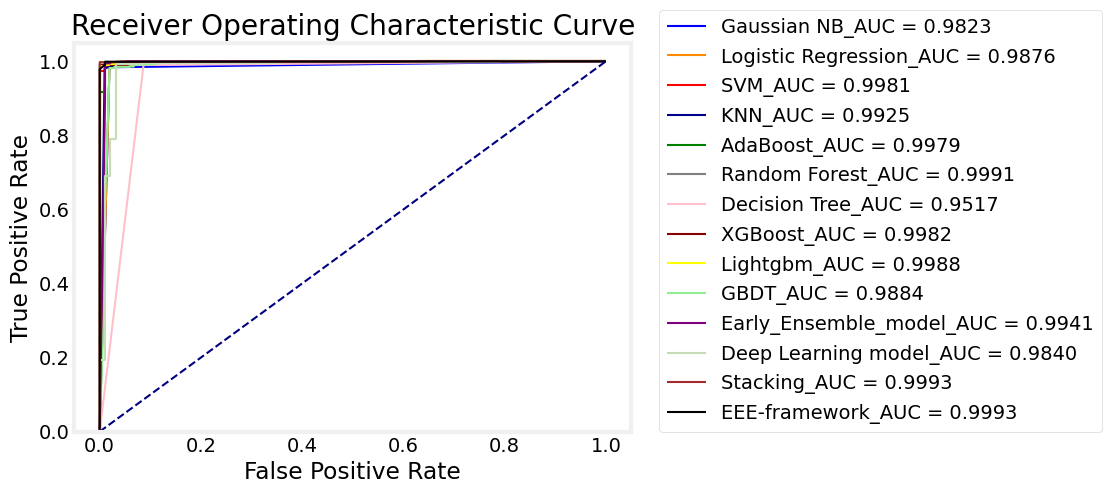

In [39]:
roc_auc_gnb_o = metrics.auc(fpr_gnb_o, tpr_gnb_o)
roc_auc_lr_o = metrics.auc(fpr_lr_o, tpr_lr_o)
roc_auc_svm_o = metrics.auc(fpr_svm_o, tpr_svm_o)
roc_auc_knn_o = metrics.auc(fpr_knn_o, tpr_knn_o)
roc_auc_ada_o= metrics.auc(fpr_ada_o, tpr_ada_o)
roc_auc_rf_o = metrics.auc(fpr_rf_o, tpr_rf_o)
roc_auc_dt_o = metrics.auc(fpr_dt_o, tpr_dt_o)
roc_auc_xgb_o = metrics.auc(fpr_xgb_o, tpr_xgb_o)
roc_auc_lgb_o = metrics.auc(fpr_lgb_o, tpr_lgb_o)
roc_auc_gbdt_o = metrics.auc(fpr_gbdt_o, tpr_gbdt_o)

roc_auc_early=metrics.auc(fpr_early,tpr_early)

roc_auc_stacking=metrics.auc(fpr_stacking,tpr_stacking)
roc_auc_voting = metrics.auc(fpr_voting, tpr_voting)
# 绘制AUC曲线
fig=plt.figure(facecolor='white')
ax = fig.add_subplot(111)
ax.patch.set_facecolor('white')
lw =1.5
plt.plot(fpr_gnb_o, tpr_gnb_o, color='#008000',lw=lw, label='Gaussian NB_AUC = %0.4f' % roc_auc_gnb_o)
plt.plot(fpr_lr_o, tpr_lr_o, color='#FFC0CB', lw=lw, label='Logistic Regression_AUC = %0.4f' % roc_auc_lr_o)
plt.plot(fpr_svm_o, tpr_svm_o, color='#ADD8E6',lw=lw, label='SVM_AUC = %0.4f' % roc_auc_svm_o)
plt.plot(fpr_knn_o, tpr_knn_o, color='#808080',lw=lw, label='KNN_AUC = %0.4f' % roc_auc_knn_o)
plt.plot(fpr_ada_o, tpr_ada_o, color='#A52A2A',lw=lw, label='AdaBoost_AUC = %0.4f' % roc_auc_ada_o)
plt.plot(fpr_rf_o, tpr_rf_o, color='#800080', lw=lw, label='Random Forest_AUC = %0.4f' % roc_auc_rf_o)
plt.plot(fpr_dt_o, tpr_dt_o, color='#FFA500',lw=lw, label='Decision Tree_AUC = %0.4f' % roc_auc_dt_o)
plt.plot(fpr_xgb_o, tpr_xgb_o, color='#FF00FF',lw=lw, label='XGBoost_AUC = %0.4f' % roc_auc_xgb_o)
plt.plot(fpr_lgb_o, tpr_lgb_o, color='#00FFFF',lw=lw, label='Lightgbm_AUC = %0.4f' % roc_auc_lgb_o)
plt.plot(fpr_gbdt_o, tpr_gbdt_o, color='#FFFF00',lw=lw, label='GBDT_AUC = %0.4f' % roc_auc_gbdt_o)

plt.plot(fpr_early,tpr_early,color='#0000FF',lw=lw,label='Early_Ensemble_model_AUC = %0.4f' % roc_auc_early)
plt.plot(fpr_deep, tpr_deep, color='#00FF00', lw=1.5, label='Deep Learning model_AUC = %0.4f' % roc_auc_deep)

plt.plot(fpr_stacking,tpr_stacking,color='#FF0000',lw=lw, label='Stacking_AUC = %0.4f' % roc_auc_stacking)
plt.plot(fpr_voting, tpr_voting, color='#000000',lw=lw, label='EEE-framework_AUC = %0.4f' % roc_auc_voting)

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc=(1.05,0),facecolor='white')
plt.grid(False)
plt.savefig('./auc-tcga-14-10yuanmodel.jpg')
plt.show()

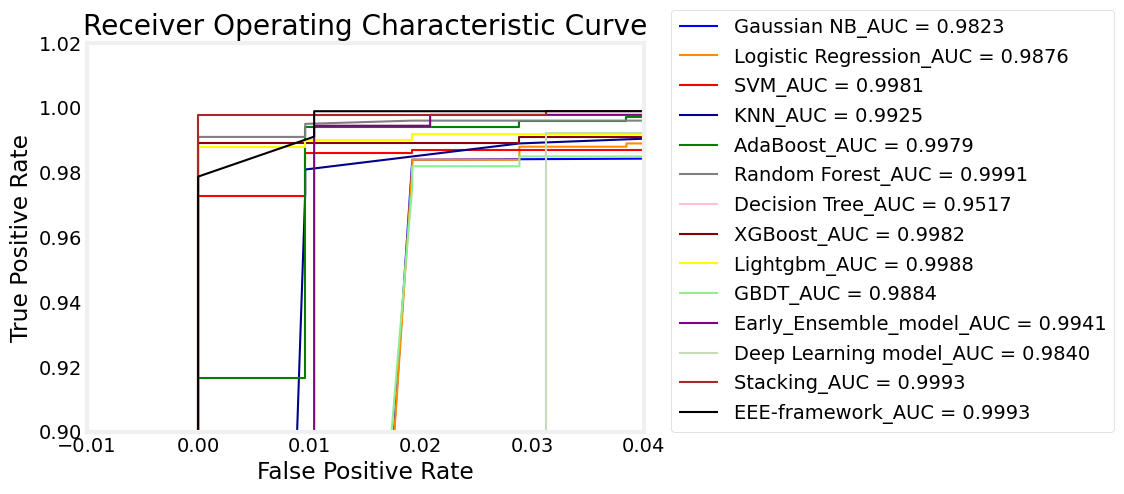

In [40]:
roc_auc_gnb_o = metrics.auc(fpr_gnb_o, tpr_gnb_o)
roc_auc_lr_o = metrics.auc(fpr_lr_o, tpr_lr_o)
roc_auc_svm_o = metrics.auc(fpr_svm_o, tpr_svm_o)
roc_auc_knn_o = metrics.auc(fpr_knn_o, tpr_knn_o)
roc_auc_ada_o= metrics.auc(fpr_ada_o, tpr_ada_o)
roc_auc_rf_o = metrics.auc(fpr_rf_o, tpr_rf_o)
roc_auc_dt_o = metrics.auc(fpr_dt_o, tpr_dt_o)
roc_auc_xgb_o = metrics.auc(fpr_xgb_o, tpr_xgb_o)
roc_auc_lgb_o = metrics.auc(fpr_lgb_o, tpr_lgb_o)
roc_auc_gbdt_o = metrics.auc(fpr_gbdt_o, tpr_gbdt_o)

roc_auc_early=metrics.auc(fpr_early,tpr_early)

roc_auc_stacking=metrics.auc(fpr_stacking,tpr_stacking)
roc_auc_voting = metrics.auc(fpr_voting, tpr_voting)
# 绘制AUC曲线
fig=plt.figure(facecolor='white')
ax = fig.add_subplot(111)
ax.patch.set_facecolor('white')
lw =1.5
plt.plot(fpr_gnb_o, tpr_gnb_o, color='#008000',lw=lw, label='Gaussian NB_AUC = %0.4f' % roc_auc_gnb_o)
plt.plot(fpr_lr_o, tpr_lr_o, color='#FFC0CB', lw=lw, label='Logistic Regression_AUC = %0.4f' % roc_auc_lr_o)
plt.plot(fpr_svm_o, tpr_svm_o, color='#ADD8E6',lw=lw, label='SVM_AUC = %0.4f' % roc_auc_svm_o)
plt.plot(fpr_knn_o, tpr_knn_o, color='#808080',lw=lw, label='KNN_AUC = %0.4f' % roc_auc_knn_o)
plt.plot(fpr_ada_o, tpr_ada_o, color='#A52A2A',lw=lw, label='AdaBoost_AUC = %0.4f' % roc_auc_ada_o)
plt.plot(fpr_rf_o, tpr_rf_o, color='#800080', lw=lw, label='Random Forest_AUC = %0.4f' % roc_auc_rf_o)
plt.plot(fpr_dt_o, tpr_dt_o, color='#FFA500',lw=lw, label='Decision Tree_AUC = %0.4f' % roc_auc_dt_o)
plt.plot(fpr_xgb_o, tpr_xgb_o, color='#FF00FF',lw=lw, label='XGBoost_AUC = %0.4f' % roc_auc_xgb_o)
plt.plot(fpr_lgb_o, tpr_lgb_o, color='#00FFFF',lw=lw, label='Lightgbm_AUC = %0.4f' % roc_auc_lgb_o)
plt.plot(fpr_gbdt_o, tpr_gbdt_o, color='#FFFF00',lw=lw, label='GBDT_AUC = %0.4f' % roc_auc_gbdt_o)

plt.plot(fpr_early,tpr_early,color='#0000FF',lw=lw,label='Early_Ensemble_model_AUC = %0.4f' % roc_auc_early)
plt.plot(fpr_deep, tpr_deep, color='#00FF00', lw=1.5, label='Deep Learning model_AUC = %0.4f' % roc_auc_deep)

plt.plot(fpr_stacking,tpr_stacking,color='#FF0000',lw=lw, label='Stacking_AUC = %0.4f' % roc_auc_stacking)
plt.plot(fpr_voting, tpr_voting, color='#000000',lw=lw, label='EEE-framework_AUC = %0.4f' % roc_auc_voting)

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.01, 0.04])
plt.ylim([0.9, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc=(1.05,0),facecolor='white')
plt.grid(False)
plt.savefig('./auc-tcga-14-10yuanmodel-part.jpg')
plt.show()

### calculate std 95%ci p-value 
### base model decision tree

In [93]:
acc_dt_o,pre_dt_o,rec_dt_o,f1_dt_o,e,y_dt_o,y_t_dt_o=crosspredict(yuan6,X_yuan,y_yuan,10)
acc_rf_o,pre_rf_o,rec_rf_o,f1_rf_o,e,y_rf_o,y_t_rf_o=crosspredict(yuan7,X_yuan,y_yuan,10)
acc_ada_o,pre_ada_o,rec_ada_o,f1_ada_o,e,y_ada_o,y_t_ada_o=crosspredict(yuan8,X_yuan,y_yuan,10)
acc_gbdt_o,pre_gbdt_o,rec_gbdt_o,f1_gbdt_o,e,y_gbdt_o,y_t_gbdt_o=crosspredict(yuan9,X_yuan,y_yuan,10)
acc_xgb_o,pre_xgb_o,rec_xgb_o,f1_xgb_o,e,y_xgb_o,y_t_xgb_o=crosspredict(yuan10,X_yuan_arr,y_yuan,10)
acc_knn_o,pre_knn_o,rec_knn_o,f1_knn_o,e,y_knn_o,y_t_knn_o=crosspredict(yuan2,X_yuan,y_yuan,10)
acc_lgb_o,pre_lgb_o,rec_lgb_o,f1_lgb_o,e,y_lgb_o,y_t_lgb_o=crosspredict(yuan11,X_yuan_arr,y_yuan,10)
acc_svm_o,pre_svm_o,rec_svm_o,f1_svm_o,e,y_svm_o,y_t_svm_o=crosspredict(yuan1,X_yuan,y_yuan,10)
acc_gnb_o,pre_gnb_o,rec_gnb_o,f1_gnb_o,e,y_gnb_o,y_t_gnb_o=crosspredict(yuan4,X_yuan,y_yuan,10)
acc_lr_o,pre_lr_o,rec_lr_o,f1_lr_o,e,y_lr_o,y_t_lr_o=crosspredict(yuan3,X_yuan,y_yuan,10)

acc_dt,pre_dt,rec_dt,f1_dt,e,y_dt,y_t_dt=crosspredict(model_dt_fs,X_pre,y,10)
acc_rf,pre_rf,rec_rf,f1_rf,e,y_rf,y_t_rf=crosspredict(model_rf_fs,X_pre,y,10)
acc_ada,pre_ada,rec_ada,f1_ada,e,y_ada,y_t_ada=crosspredict(model_ada_fs,X_pre,y,10)
acc_gbdt,pre_gbdt,rec_gbdt,f1_gbdt,e,y_gbdt,y_t_gbdt=crosspredict(model_gb_fs,X_pre,y,10)
acc_xgb,pre_xgb,rec_xgb,f1_xgb,e,y_xgb,y_t_xgb=crosspredict(model_xgb_fs,X_pre,y,10)
acc_knn,pre_knn,rec_knn,f1_knn,e,y_knn,y_t_knn=crosspredict(model_KN_fs,X_pre,y,10)
acc_lgb,pre_lgb,rec_lgb,f1_lgb,e,y_lgb,y_t_lgb=crosspredict(model_Lightgbm_fs,X_pre,y,10)
acc_svm,pre_svm,rec_svm,f1_svm,e,y_svm,y_t_svm=crosspredict(model_SVC_fs,X_pre,y,10)
acc_gnb,pre_gnb,rec_gnb,f1_gnb,e,y_gnb,y_t_gnb=crosspredict(model_GNB_fs,X_pre,y,10)
acc_lr,pre_lr,rec_lr,f1_lr,e,y_lr,y_t_lr=crosspredict(model_lr_fs,X_pre,y,10)

acc_early,pre_early,rec_early,f1_early,e,y_early,y_t_early=crosspredict(early,X_pre,y,10)
acc_stacking,pre_stacking,rec_stacking,f1_stacking,e,y_stacking,y_t_stacking=crosspredict(model_Stacking_cross,X_pre,y,10)
acc_voting,pre_voting,rec_voting,f1_voting,e,y_voting,y_t_voting=crosspredict(model_voting_hard,X_pre,y,10)

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[ 93   3]
 [  2 890]]
the accuracy of the model is :  0.9949392712550608
the precision score of the model is :  0.9966405375139977
the recall score of the model is : 0.9977578475336323
the f1_score of the model  is : 0.9971988795518206
the weighted_f1 of the model is : 0.9949274408451301
the classification_report is :
               precision    recall  f1-score   support

           0     0.9789    0.9688    0.9738        96
           1     0.9966    0.9978    0.9972       892

    accuracy                         0.9949       988
   macro avg     0.9878    0.9833    0.9855       988
weighted avg     0.9949    0.9949    0.9949       988

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[ 93   3]
 [  9 883]]
the accuracy of the model is :  0.9878542510121457
the precision score of the model is :  0.9966139954853274
the recall score of the model is : 0.9899103139013453

In [94]:
# 创建数据
data_model_14 =  {
    'Accuracy': [acc_dt_o, acc_svm_o, acc_knn_o,acc_lr_o,acc_gnb_o,acc_rf_o,acc_ada_o,
                acc_gbdt_o,acc_xgb_o,acc_lgb_o,acc_early,overall_accuracy_deep,acc_stacking,acc_voting],
    'Precision': [pre_dt_o, pre_svm_o, pre_knn_o, pre_lr_o, pre_gnb_o, pre_rf_o, pre_ada_o,
                  pre_gbdt_o, pre_xgb_o, pre_lgb_o, pre_early, overall_precision_deep, pre_stacking, pre_voting],
    'Recall': [rec_dt_o, rec_svm_o, rec_knn_o, rec_lr_o, rec_gnb_o, rec_rf_o, rec_ada_o,
               rec_gbdt_o, rec_xgb_o, rec_lgb_o, rec_early, overall_recall_deep, rec_stacking, rec_voting],
    'F1_score':[f1_dt_o, f1_svm_o, f1_knn_o, f1_lr_o, f1_gnb_o, f1_rf_o, f1_ada_o, 
                f1_gbdt_o, f1_xgb_o, f1_lgb_o, f1_early, overall_f1_deep, f1_stacking, f1_voting],
    'AUC':[roc_auc_dt_o,roc_auc_svm_o,roc_auc_knn_o,roc_auc_lr_o,roc_auc_gnb_o,roc_auc_rf_o,roc_auc_ada_o,
           roc_auc_gbdt_o,roc_auc_xgb_o,roc_auc_lgb_o,roc_auc_early,roc_auc_deep,roc_auc_stacking,roc_auc_voting]
}
index = ['Decision Tree', 'SVM', 'KNN','Logistic Regression','Gaussian NB','Random Forest','AdaBoost',
         'GBDT','XGBoost','Lightgbm','Early Ensemble','Deep Learning','Stacking','Our EEE-framework']

# 创建DataFrame
df_model_14= pd.DataFrame(data_model_14, index=index)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [95]:
df_model_14

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,0.9818,0.9890,0.9909,0.9899,0.9517
SVM,0.9854,0.9920,0.9920,0.9920,0.9981
KNN,0.9854,0.9959,0.9879,0.9919,0.9925
Logistic Regression,0.9891,0.9930,0.9950,0.9940,0.9876
Gaussian NB,0.9854,0.9990,0.9849,0.9919,0.9823
Random Forest,0.9945,0.9970,0.9970,0.9970,0.9991
AdaBoost,0.9918,0.9960,0.9950,0.9955,0.9979
GBDT,0.9818,0.9899,0.9899,0.9899,0.9884
XGBoost,0.9909,0.9960,0.9940,0.9950,0.9982
Lightgbm,0.9909,0.9950,0.9950,0.9950,0.9988


In [96]:
df_model_14.to_csv('./model_14_yuan.csv')

In [97]:
# 创建数据
data_model_24 = {
    'Accuracy': [acc_dt_o, acc_dt,
                 acc_svm_o,acc_svm, 
                 acc_knn_o,acc_knn,
                 acc_lr_o,acc_lr,
                 acc_gnb_o,acc_gnb,
                 acc_rf_o,acc_rf,
                 acc_ada_o,acc_ada,
                 acc_gbdt_o,acc_gbdt,
                 acc_xgb_o,acc_xgb,
                 acc_lgb_o,acc_lgb,
                 acc_early,overall_accuracy_deep,acc_stacking,acc_voting],
    'Precision': [pre_dt_o,pre_dt, 
                  pre_svm_o,pre_svm, 
                  pre_knn_o, pre_knn,
                  pre_lr_o, pre_lr,
                  pre_gnb_o, pre_gnb,
                  pre_rf_o, pre_rf,
                  pre_ada_o,pre_ada,
                  pre_gbdt_o,pre_gbdt, 
                  pre_xgb_o,pre_xgb, 
                  pre_lgb_o,pre_lgb, 
                  pre_early, overall_precision_deep, pre_stacking, pre_voting],
    'Recall': [rec_dt_o, rec_dt,
               rec_svm_o,rec_svm, 
               rec_knn_o, rec_knn,
               rec_lr_o, rec_lr,
               rec_gnb_o,rec_gnb, 
               rec_rf_o, rec_rf,
               rec_ada_o,rec_ada,
               rec_gbdt_o,rec_gbdt, 
               rec_xgb_o,rec_xgb, 
               rec_lgb_o, rec_lgb,
               rec_early, overall_recall_deep, rec_stacking, rec_voting],
    'F1_score':[f1_dt_o,f1_dt, 
                f1_svm_o,f1_svm, 
                f1_knn_o,f1_knn, 
                f1_lr_o,f1_lr, 
                f1_gnb_o, f1_gnb,
                f1_rf_o,f1_rf, 
                f1_ada_o, f1_ada,
                f1_gbdt_o,f1_gbdt, 
                f1_xgb_o,f1_xgb, 
                f1_lgb_o,f1_lgb, 
                f1_early, overall_f1_deep, f1_stacking, f1_voting],
    'AUC':[roc_auc_dt_o,roc_auc_dt,
           roc_auc_svm_o,roc_auc_svm,
           roc_auc_knn_o,roc_auc_knn,
           roc_auc_lr_o,roc_auc_lr,
           roc_auc_gnb_o,roc_auc_gnb,
           roc_auc_rf_o,roc_auc_rf,
           roc_auc_ada_o,roc_auc_ada,
           roc_auc_gbdt_o,roc_auc_gbdt,
           roc_auc_xgb_o,roc_auc_xgb,
           roc_auc_lgb_o,roc_auc_lgb,
           roc_auc_early,roc_auc_deep,roc_auc_stacking,roc_auc_voting]
}
index_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework',]

# 创建DataFrame
df_model_24= pd.DataFrame(data_model_24, index=index_24)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [98]:
df_model_24

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,0.9818,0.9890,0.9909,0.9899,0.9517
Decision Tree+,0.9889,0.9922,0.9955,0.9938,0.9818
SVM,0.9854,0.9920,0.9920,0.9920,0.9981
SVM+,0.9949,0.9966,0.9978,0.9972,0.9992
KNN,0.9854,0.9959,0.9879,0.9919,0.9925
KNN+,0.9879,0.9966,0.9899,0.9933,0.9818
Logistic Regression,0.9891,0.9930,0.9950,0.9940,0.9876
Logistic Regression+,0.9605,0.9591,0.9989,0.9786,0.9979
Gaussian NB,0.9854,0.9990,0.9849,0.9919,0.9823
Gaussian NB+,0.9909,1.0000,0.9899,0.9949,0.9980


In [99]:
df_model_24.to_csv('./model_24.csv')

In [44]:
# 创建数据
data_model_std_14 = {
    'Accuracy': [data9_acc.std(), data1_acc.std(), data3_acc.std(), data5_acc.std(), data7_acc.std(), data11_acc.std(), data13_acc.std(),
                 data15_acc.std(), data17_acc.std(), data19_acc.std(), data21_acc.std(), data22_acc.std(), data23_acc.std(), data24_acc.std()],
    'Precision': [data9_pre.std(), data1_pre.std(), data3_pre.std(), data5_pre.std(), data7_pre.std(), data11_pre.std(), data13_pre.std(),
                  data15_pre.std(), data17_pre.std(), data19_pre.std(), data21_pre.std(), data22_pre.std(), data23_pre.std(), data24_pre.std()],
    'Recall': [data9_rec.std(), data1_rec.std(), data3_rec.std(), data5_rec.std(), data7_rec.std(), data11_rec.std(), data13_rec.std(),
               data15_rec.std(), data17_rec.std(), data19_rec.std(), data21_rec.std(), data22_rec.std(), data23_rec.std(), data24_rec.std()],
    'F1_score': [data9_f1.std(), data1_f1.std(), data3_f1.std(), data5_f1.std(), data7_f1.std(), data11_f1.std(), data13_f1.std(),
                 data15_f1.std(), data17_f1.std(), data19_f1.std(), data21_f1.std(), data22_f1.std(), data23_f1.std(), data24_f1.std()],
    'AUC':[data9_auc.std(), data1_auc.std(), data3_auc.std(), data5_auc.std(), data7_auc.std(), data11_auc.std(), data13_auc.std(),
            data15_auc.std(), data17_auc.std(), data19_auc.std(), data21_auc.std(), data22_auc.std(), data23_auc.std(), data24_auc.std()]
}
index_std = ['Decision Tree', 'SVM', 'KNN','Logistic Regression','Gaussian NB','Random Forest','AdaBoost',
         'GBDT','XGBoost','Lightgbm','Early Ensemble','Deep Learning','Stacking','Our EEE-framework']

# 创建DataFrame
df_model_std_14= pd.DataFrame(data_model_std_14, index=index_std)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [45]:
df_model_std_14.to_csv('./model_std_14_yuan.csv')

In [46]:
df_model_std_14

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,0.0107,0.0096,0.0100,0.0059,0.0472
SVM,0.0115,0.0052,0.0104,0.0064,0.0026
KNN,0.0176,0.0032,0.0191,0.0100,0.0165
Logistic Regression,0.0114,0.0070,0.0082,0.0063,0.0174
Gaussian NB,0.0115,0.0049,0.0125,0.0064,0.0232
Random Forest,0.0052,0.0052,0.0068,0.0029,0.0009
AdaBoost,0.0064,0.0048,0.0048,0.0035,0.0007
GBDT,0.0112,0.0092,0.0082,0.0062,0.0158
XGBoost,0.0074,0.0042,0.0079,0.0041,0.0008
Lightgbm,0.0072,0.0042,0.0070,0.0040,0.0013


In [47]:
# 创建数据
data_model_std_24 = {
    'Accuracy': [data9_acc.std(), data10_acc.std(),
                 data1_acc.std(), data2_acc.std(),
                 data3_acc.std(), data4_acc.std(),
                 data5_acc.std(), data6_acc.std(),
                 data7_acc.std(), data8_acc.std(),
                 data11_acc.std(), data12_acc.std(),
                 data13_acc.std(), data14_acc.std(),
                 data15_acc.std(), data16_acc.std(),
                 data17_acc.std(), data18_acc.std(),
                 data19_acc.std(), data20_acc.std(),
                 data21_acc.std(), data22_acc.std(), data23_acc.std(), data24_acc.std()],
    'Precision': [data9_pre.std(), data10_pre.std(), 
                  data1_pre.std(), data2_pre.std(), 
                  data3_pre.std(), data4_pre.std(), 
                  data5_pre.std(), data6_pre.std(), 
                  data7_pre.std(), data8_pre.std(), 
                  data11_pre.std(), data12_pre.std(), 
                  data13_pre.std(), data14_pre.std(), 
                  data15_pre.std(), data16_pre.std(), 
                  data17_pre.std(), data18_pre.std(), 
                  data19_pre.std(), data20_pre.std(), 
                  data21_pre.std(), data22_pre.std(), data23_pre.std(), data24_pre.std()],
    'Recall': [data9_rec.std(), data10_rec.std(),
               data1_rec.std(), data2_rec.std(),
               data3_rec.std(), data4_rec.std(),
               data5_rec.std(), data6_rec.std(),
               data7_rec.std(), data8_rec.std(),
               data11_rec.std(), data12_rec.std(),
               data13_rec.std(), data14_rec.std(),
               data15_rec.std(), data16_rec.std(),
               data17_rec.std(), data18_rec.std(),
               data19_rec.std(), data20_rec.std(),
               data21_rec.std(), data22_rec.std(), data23_rec.std(), data24_rec.std()],
    'F1_score': [data9_f1.std(), data10_f1.std(), 
                 data1_f1.std(), data2_f1.std(), 
                 data3_f1.std(), data4_f1.std(), 
                 data5_f1.std(), data6_f1.std(), 
                 data7_f1.std(), data7_f1.std(), 
                 data11_f1.std(), data12_f1.std(), 
                 data13_f1.std(), data14_f1.std(), 
                 data15_f1.std(), data16_f1.std(), 
                 data17_f1.std(), data18_f1.std(), 
                 data19_f1.std(), data20_f1.std(), 
                 data21_f1.std(), data22_f1.std(), data23_f1.std(), data24_f1.std()],
    'AUC':[data9_auc.std(), data10_auc.std(), 
           data1_auc.std(), data2_auc.std(), 
           data3_auc.std(), data4_auc.std(), 
           data5_auc.std(), data6_auc.std(), 
           data7_auc.std(), data8_auc.std(), 
           data11_auc.std(), data12_auc.std(), 
           data13_auc.std(), data14_auc.std(), 
           data15_auc.std(), data16_auc.std(), 
           data17_auc.std(), data18_auc.std(), 
           data19_auc.std(), data20_auc.std(), 
           data21_auc.std(), data22_auc.std(), data23_auc.std(), data24_auc.std()]
}
index_std_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework']

# 创建DataFrame
df_model_std_24= pd.DataFrame(data_model_std_24, index=index_std_24)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [48]:
df_model_std_24

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,0.0107,0.0096,0.0100,0.0059,0.0472
Decision Tree+,0.0093,0.0075,0.0083,0.0052,0.0372
SVM,0.0115,0.0052,0.0104,0.0064,0.0026
SVM+,0.0071,0.0070,0.0054,0.0040,0.0000
KNN,0.0176,0.0032,0.0191,0.0100,0.0165
KNN+,0.0086,0.0054,0.0103,0.0048,0.0205
Logistic Regression,0.0114,0.0070,0.0082,0.0063,0.0174
Logistic Regression+,0.0072,0.0035,0.0078,0.0040,0.0036
Gaussian NB,0.0115,0.0049,0.0125,0.0064,0.0232
Gaussian NB+,0.0130,0.0000,0.0143,0.0064,0.0029


In [49]:
df_model_std_24.to_csv('./model_std_24.csv')

In [50]:
def calculate_confidence_interval(data, confidence_level=0.95):
    """
    计算置信区间
    :param data: 样本数据（列表或numpy数组）
    :param confidence_level: 置信水平（默认为0.95）
    :return: 置信区间（下限，上限）
    """
    # 计算样本均值
    mean = np.mean(data)
    
    # 计算样本标准差
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    
    # 计算自由度
    df = len(data) - 1
    
    # 计算置信区间
    interval = stats.t.interval(confidence_level, df, loc=mean, scale=std_err)
    
    return interval

In [51]:
data_model_interval_14 = {
    'Accuracy': [calculate_confidence_interval(data9_acc), calculate_confidence_interval(data1_acc), 
                 calculate_confidence_interval(data3_acc), calculate_confidence_interval(data5_acc), 
                 calculate_confidence_interval(data7_acc), calculate_confidence_interval(data11_acc), 
                 calculate_confidence_interval(data13_acc), calculate_confidence_interval(data15_acc), 
                 calculate_confidence_interval(data17_acc), calculate_confidence_interval(data19_acc), 
                 calculate_confidence_interval(data21_acc), calculate_confidence_interval(data22_acc), 
                 calculate_confidence_interval(data23_acc), calculate_confidence_interval(data24_acc)],
    'Precision': [calculate_confidence_interval(data9_pre), calculate_confidence_interval(data1_pre), 
                  calculate_confidence_interval(data3_pre), calculate_confidence_interval(data5_pre), 
                  calculate_confidence_interval(data7_pre), calculate_confidence_interval(data11_pre), 
                  calculate_confidence_interval(data13_pre), calculate_confidence_interval(data15_pre), 
                  calculate_confidence_interval(data17_pre), calculate_confidence_interval(data19_pre), 
                  calculate_confidence_interval(data21_pre), calculate_confidence_interval(data22_pre), 
                  calculate_confidence_interval(data23_pre), calculate_confidence_interval(data24_pre)],
    'Recall': [calculate_confidence_interval(data9_rec), calculate_confidence_interval(data1_rec), 
               calculate_confidence_interval(data3_rec), calculate_confidence_interval(data5_rec), 
               calculate_confidence_interval(data7_rec), calculate_confidence_interval(data11_rec), 
               calculate_confidence_interval(data13_rec), calculate_confidence_interval(data15_rec), 
               calculate_confidence_interval(data17_rec), calculate_confidence_interval(data19_rec), 
               calculate_confidence_interval(data21_rec), calculate_confidence_interval(data22_rec), 
               calculate_confidence_interval(data23_rec), calculate_confidence_interval(data24_rec)],
    'F1_score': [calculate_confidence_interval(data9_f1), calculate_confidence_interval(data1_f1), 
                 calculate_confidence_interval(data3_f1), calculate_confidence_interval(data5_f1), 
                 calculate_confidence_interval(data7_f1), calculate_confidence_interval(data11_f1), 
                 calculate_confidence_interval(data13_f1), calculate_confidence_interval(data15_f1), 
                 calculate_confidence_interval(data17_f1), calculate_confidence_interval(data19_f1), 
                 calculate_confidence_interval(data21_f1), calculate_confidence_interval(data22_f1), 
                 calculate_confidence_interval(data23_f1), calculate_confidence_interval(data24_f1)],
    'AUC':[calculate_confidence_interval(data9_auc), calculate_confidence_interval(data1_auc), 
            calculate_confidence_interval(data3_auc), calculate_confidence_interval(data5_auc), 
            calculate_confidence_interval(data7_auc), calculate_confidence_interval(data11_auc), 
            calculate_confidence_interval(data13_auc), calculate_confidence_interval(data15_auc), 
            calculate_confidence_interval(data17_auc), calculate_confidence_interval(data19_auc), 
            calculate_confidence_interval(data21_auc), calculate_confidence_interval(data22_auc), 
            calculate_confidence_interval(data23_auc), calculate_confidence_interval(data24_auc)]
}
index_interval = ['Decision Tree', 'SVM', 'KNN','Logistic Regression','Gaussian NB','Random Forest','AdaBoost',
         'GBDT','XGBoost','Lightgbm','Early Ensemble','Deep Learning','Stacking','Our EEE-framework']

# 创建DataFrame
df_model_interval_14= pd.DataFrame(data_model_interval_14, index=index_interval)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [52]:
df_model_interval_14.to_csv('./model_interval_14_yuan.csv')

In [53]:
df_model_interval_14

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,"(0.9795870072229826, 0.9949084056210542)","(0.9882124533759249, 1.0018849916626966)","(0.9838101843777551, 0.9981090075414367)","(0.9887257305061807, 0.9971622345655495)","(0.9371724508084717, 1.004696236060215)"
SVM,"(0.9771813221833778, 0.9936777270242951)","(0.9922265504479334, 0.9996914168590013)","(0.9805292345142816, 0.9953495533645061)","(0.9873263794231516, 0.996491032462676)","(0.9961775966044695, 0.9999491251586161)"
KNN,"(0.9674149429500828, 0.9925350153484996)","(0.9967048917546928, 1.0012749062251052)","(0.9652535219523662, 0.9925848618860177)","(0.9816051450242292, 0.9959222773513238)","(0.9773221911807227, 1.0009131623546308)"
Logistic Regression,"(0.9800109866695903, 0.9963026079926283)","(0.9889687100231176, 0.9989908859364783)","(0.987071485850819, 0.9988679080885748)","(0.9889689490898635, 0.997945166171878)","(0.9804534283587797, 1.0053008416136722)"
Gaussian NB,"(0.9772233025860951, 0.9936691077558565)","(0.9935009708727434, 1.0004586250868526)","(0.9779922665874868, 0.9959067233115032)","(0.9872970140008168, 0.9964895756238827)","(0.9622989606657184, 0.9955596251928673)"
Random Forest,"(0.9863012373485456, 0.9936820820843153)","(0.9923053741313043, 0.9996942258286915)","(0.9881305860660903, 0.9978088078733036)","(0.9924042810868492, 0.9965097326418204)","(0.9989856094310493, 1.0002634263816228)"
AdaBoost,"(0.9899861773312977, 0.9990880511924722)","(0.9935227063836644, 1.0004570915961337)","(0.9935227063836644, 1.0004570915961337)","(0.994458281105152, 0.9995014163721335)","(0.9992317693797711, 1.0001845758911196)"
GBDT,"(0.9755786007117784, 0.9916107237252529)","(0.985430520130974, 0.9985480654826896)","(0.9840887743299603, 0.9958102155690295)","(0.9865059723657507, 0.9953626606521823)","(0.9816701048162481, 1.004272962217728)"
XGBoost,"(0.9855908401257478, 0.9962106611252948)","(0.9949584082147013, 1.0010213897650966)","(0.9863328345942355, 0.9976267613653607)","(0.9920045909129401, 0.9979044992231733)","(0.9988338976382269, 0.9999987929035545)"
Lightgbm,"(0.9875974442070081, 0.9978571012475375)","(0.9949837904495279, 1.0010162095504722)","(0.9889687100231176, 0.9989908859364783)","(0.9931318522607001, 0.9988074386150497)","(0.9982907591039392, 1.0001746219796237)"


In [54]:
data_model_interval_24 = {
    'Accuracy': [calculate_confidence_interval(data9_acc), calculate_confidence_interval(data10_acc),
                 calculate_confidence_interval(data1_acc), calculate_confidence_interval(data2_acc),
                 calculate_confidence_interval(data3_acc), calculate_confidence_interval(data4_acc),
                 calculate_confidence_interval(data5_acc), calculate_confidence_interval(data6_acc),
                 calculate_confidence_interval(data7_acc), calculate_confidence_interval(data8_acc),
                 calculate_confidence_interval(data11_acc), calculate_confidence_interval(data12_acc),
                 calculate_confidence_interval(data13_acc), calculate_confidence_interval(data14_acc),
                 calculate_confidence_interval(data15_acc), calculate_confidence_interval(data16_acc),
                 calculate_confidence_interval(data17_acc), calculate_confidence_interval(data18_acc),
                 calculate_confidence_interval(data19_acc), calculate_confidence_interval(data20_acc),
                 calculate_confidence_interval(data21_acc), 
                 calculate_confidence_interval(data22_acc), 
                 calculate_confidence_interval(data23_acc), 
                 calculate_confidence_interval(data24_acc)],
    'Precision': [calculate_confidence_interval(data9_pre), calculate_confidence_interval(data10_pre),
                  calculate_confidence_interval(data1_pre), calculate_confidence_interval(data2_pre),
                  calculate_confidence_interval(data3_pre), calculate_confidence_interval(data4_pre),
                  calculate_confidence_interval(data5_pre), calculate_confidence_interval(data6_pre),
                  calculate_confidence_interval(data7_pre), calculate_confidence_interval(data8_pre),
                  calculate_confidence_interval(data11_pre), calculate_confidence_interval(data12_pre),
                  calculate_confidence_interval(data13_pre), calculate_confidence_interval(data14_pre),
                  calculate_confidence_interval(data15_pre), calculate_confidence_interval(data16_pre),
                  calculate_confidence_interval(data17_pre), calculate_confidence_interval(data18_pre),
                  calculate_confidence_interval(data19_pre), calculate_confidence_interval(data20_pre),
                  calculate_confidence_interval(data21_pre), 
                  calculate_confidence_interval(data22_pre), 
                  calculate_confidence_interval(data23_pre), 
                  calculate_confidence_interval(data24_pre)],
    'Recall': [calculate_confidence_interval(data9_rec), calculate_confidence_interval(data10_rec), 
               calculate_confidence_interval(data1_rec), calculate_confidence_interval(data2_rec), 
               calculate_confidence_interval(data3_rec), calculate_confidence_interval(data4_rec), 
               calculate_confidence_interval(data5_rec), calculate_confidence_interval(data6_rec), 
               calculate_confidence_interval(data7_rec), calculate_confidence_interval(data8_rec), 
               calculate_confidence_interval(data11_rec), calculate_confidence_interval(data12_rec), 
               calculate_confidence_interval(data13_rec), calculate_confidence_interval(data14_rec), 
               calculate_confidence_interval(data15_rec), calculate_confidence_interval(data16_rec), 
               calculate_confidence_interval(data17_rec), calculate_confidence_interval(data18_rec), 
               calculate_confidence_interval(data19_rec), calculate_confidence_interval(data20_rec), 
               calculate_confidence_interval(data21_rec), 
               calculate_confidence_interval(data22_rec), 
               calculate_confidence_interval(data23_rec), 
               calculate_confidence_interval(data24_rec)],
    'F1_score': [calculate_confidence_interval(data9_f1), calculate_confidence_interval(data10_f1),
                 calculate_confidence_interval(data1_f1), calculate_confidence_interval(data2_f1),
                 calculate_confidence_interval(data3_f1), calculate_confidence_interval(data4_f1),
                 calculate_confidence_interval(data5_f1), calculate_confidence_interval(data6_f1),
                 calculate_confidence_interval(data7_f1), calculate_confidence_interval(data8_f1),
                 calculate_confidence_interval(data11_f1), calculate_confidence_interval(data12_f1),
                 calculate_confidence_interval(data13_f1), calculate_confidence_interval(data14_f1),
                 calculate_confidence_interval(data15_f1), calculate_confidence_interval(data16_f1),
                 calculate_confidence_interval(data17_f1), calculate_confidence_interval(data18_f1),
                 calculate_confidence_interval(data19_f1), calculate_confidence_interval(data20_f1),
                 calculate_confidence_interval(data21_f1), 
                 calculate_confidence_interval(data22_f1), 
                 calculate_confidence_interval(data23_f1), 
                 calculate_confidence_interval(data24_f1)],
    'AUC':[calculate_confidence_interval(data9_auc), calculate_confidence_interval(data10_auc), 
           calculate_confidence_interval(data1_auc), calculate_confidence_interval(data2_auc), 
            calculate_confidence_interval(data3_auc), calculate_confidence_interval(data4_auc), 
           calculate_confidence_interval(data5_auc), calculate_confidence_interval(data6_auc), 
            calculate_confidence_interval(data7_auc), calculate_confidence_interval(data8_auc), 
           calculate_confidence_interval(data11_auc), calculate_confidence_interval(data12_auc), 
            calculate_confidence_interval(data13_auc), calculate_confidence_interval(data14_auc), 
           calculate_confidence_interval(data15_auc), calculate_confidence_interval(data16_auc), 
            calculate_confidence_interval(data17_auc), calculate_confidence_interval(data18_auc), 
           calculate_confidence_interval(data19_auc), calculate_confidence_interval(data20_auc), 
            calculate_confidence_interval(data21_auc), 
           calculate_confidence_interval(data22_auc), 
            calculate_confidence_interval(data23_auc), 
           calculate_confidence_interval(data24_auc)]
}
index_interval_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework']

# 创建DataFrame
df_model_interval_24= pd.DataFrame(data_model_interval_24, index=index_interval_24)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [55]:
df_model_interval_24.to_csv('./model_interval_24.csv')

In [56]:
df_model_interval_24

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,"(0.9795870072229826, 0.9949084056210542)","(0.9882124533759249, 1.0018849916626966)","(0.9838101843777551, 0.9981090075414367)","(0.9887257305061807, 0.9971622345655495)","(0.9371724508084717, 1.004696236060215)"
Decision Tree+,"(0.9811951335573643, 0.9945005992812255)","(0.9913285542960995, 1.0020031140355687)","(0.983984430820203, 0.9958407876567006)","(0.9895375286599472, 0.9969532239566458)","(0.953941394818181, 1.0071072943203958)"
SVM,"(0.9771813221833778, 0.9936777270242951)","(0.9922265504479334, 0.9996914168590013)","(0.9805292345142816, 0.9953495533645061)","(0.9873263794231516, 0.996491032462676)","(0.9961775966044695, 0.9999491251586161)"
SVM+,"(0.9898400634424952, 1.0000589264564947)","(0.9928304238179031, 1.0027739717864925)","(0.9927466268042451, 1.000511800162047)","(0.9943677668323445, 1.0000201804369586)","(nan, nan)"
KNN,"(0.9674149429500828, 0.9925350153484996)","(0.9967048917546928, 1.0012749062251052)","(0.9652535219523662, 0.9925848618860177)","(0.9816051450242292, 0.9959222773513238)","(0.9773221911807227, 1.0009131623546308)"
KNN+,"(0.9786966670186183, 0.9909590740656944)","(0.9927725681842576, 1.0005102600985707)","(0.9791830408516633, 0.9939255733805465)","(0.9880633285295051, 0.9949993492036509)","(0.971141119981787, 1.0004693669095985)"
Logistic Regression,"(0.9800109866695903, 0.9963026079926283)","(0.9889687100231176, 0.9989908859364783)","(0.987071485850819, 0.9988679080885748)","(0.9889689490898635, 0.997945166171878)","(0.9804534283587797, 1.0053008416136722)"
Logistic Regression+,"(0.98978459715892, 1.0000731641274128)","(0.9964152119089515, 1.0013869858932463)","(0.9899065330775222, 1.0011296716665474)","(0.9943292213094077, 1.0000458171035953)","(0.9956904041577185, 1.00082228831003)"
Gaussian NB,"(0.9772233025860951, 0.9936691077558565)","(0.9935009708727434, 1.0004586250868526)","(0.9779922665874868, 0.9959067233115032)","(0.9872970140008168, 0.9964895756238827)","(0.9622989606657184, 0.9955596251928673)"
Gaussian NB+,"(0.9795593479443134, 0.9981772012208072)","(nan, nan)","(0.9774376132881561, 0.9979431607443032)","(0.988529260841256, 0.9989899995593602)","(0.9968062092307554, 1.0009022107997618)"


In [57]:
def zhengtai(datazhengtai):
    
    shapiro_result = stats.shapiro(datazhengtai)
    print("Shapiro-Wilk Test:")
    print(f"Statistic: {shapiro_result.statistic}, p-value: {shapiro_result.pvalue}")
    
    # 判断是否正态
    if shapiro_result.pvalue > 0.05:
        print("数据符合正态分布")
        return 1
    else:
        print("数据不符合正态分布")
        return 0

nowacc = [data1_acc, data2_acc, data3_acc, data4_acc, data5_acc, data6_acc, data7_acc, data8_acc, data9_acc, data10_acc, data11_acc, data12_acc, data13_acc, data14_acc, data15_acc, data16_acc, data17_acc, data18_acc, data19_acc, data20_acc, data21_acc, data22_acc, data23_acc, data24_acc]

nowpre = [data1_pre, data2_pre, data3_pre, data4_pre, data5_pre, data6_pre, data7_pre, data8_pre, data9_pre, data10_pre, data11_pre, data12_pre, data13_pre, data14_pre, data15_pre, data16_pre, data17_pre, data18_pre, data19_pre, data20_pre, data21_pre, data22_pre, data23_pre, data24_pre]

nowrec = [data1_rec, data2_rec, data3_rec, data4_rec, data5_rec, data6_rec, data7_rec, data8_rec, data9_rec, data10_rec, data11_rec, data12_rec, data13_rec, data14_rec, data15_rec, data16_rec, data17_rec, data18_rec, data19_rec, data20_rec, data21_rec, data22_rec, data23_rec, data24_rec]

nowf1 = [data1_f1, data2_f1, data3_f1, data4_f1, data5_f1, data6_f1, data7_f1, data8_f1, data9_f1, data10_f1, data11_f1, data12_f1, data13_f1, data14_f1, data15_f1, data16_f1, data17_f1, data18_f1, data19_f1, data20_f1, data21_f1, data22_f1, data23_f1, data24_f1]

nowauc = [data1_auc, data2_auc, data3_auc, data4_auc, data5_auc, data6_auc, data7_auc, data8_auc, data9_auc, data10_auc, data11_auc, data12_auc, data13_auc, data14_auc, data15_auc, data16_auc, data17_auc, data18_auc, data19_auc, data20_auc, data21_auc, data22_auc, data23_auc, data24_auc]
acct=[]
pret=[]
rect=[]
f1t=[]
auct=[]
for i in range(24):
    print(i+1)
    acct.append(zhengtai(nowacc[i]))
    print(zhengtai(nowacc[i]))

for i in range(24):
    print(i+1)
    pret.append(zhengtai(nowpre[i]))
    print(zhengtai(nowpre[i]))

for i in range(24):
    print(i+1)
    rect.append(zhengtai(nowrec[i]))
    print(zhengtai(nowrec[i]))

for i in range(24):
    print(i+1)
    f1t.append(zhengtai(nowf1[i]))
    print(zhengtai(nowf1[i]))

for i in range(24):
    print(i+1)
    auct.append(zhengtai(nowauc[i]))
    print(zhengtai(nowauc[i]))

1
Shapiro-Wilk Test:
Statistic: 0.9293298920222588, p-value: 0.441333387719418
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9293298920222588, p-value: 0.441333387719418
数据符合正态分布
1
2
Shapiro-Wilk Test:
Statistic: 0.7308720174230467, p-value: 0.0020879422626686843
数据不符合正态分布
Shapiro-Wilk Test:
Statistic: 0.7308720174230467, p-value: 0.0020879422626686843
数据不符合正态分布
0
3
Shapiro-Wilk Test:
Statistic: 0.8137059122522778, p-value: 0.02126451581753801
数据不符合正态分布
Shapiro-Wilk Test:
Statistic: 0.8137059122522778, p-value: 0.02126451581753801
数据不符合正态分布
0
4
Shapiro-Wilk Test:
Statistic: 0.6305758774079306, p-value: 0.00012829513509092136
数据不符合正态分布
Shapiro-Wilk Test:
Statistic: 0.6305758774079306, p-value: 0.00012829513509092136
数据不符合正态分布
0
5
Shapiro-Wilk Test:
Statistic: 0.8728394866263262, p-value: 0.10786670925443742
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.8728394866263262, p-value: 0.10786670925443742
数据符合正态分布
1
6
Shapiro-Wilk Test:
Statistic: 0.7303422408058611, p-value: 0.002057198552999094
数据不符合正

In [58]:
for i in range(24):
    if acct[i]==0:
        print(i+1,end='、')

2、3、4、6、8、11、12、13、14、16、17、18、19、20、21、22、23、24、

In [59]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾 Mann-Whitney U 检验的 p 值
def right_tailed_mannwhitneyu_test(sample1, sample2):
    u_statistic, p_value = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value

# 使用 Accuracy 数据进行右尾检验
# 删除对基础模型自身的检验，因为没有意义

# T 检验部分
t_statistic, p_value_acc_1 = right_tailed_ttest(data1_acc, data9_acc, equal_var=False)
print("svc:", p_value_acc_1)

t_statistic, p_value_acc_5 = right_tailed_ttest(data5_acc, data9_acc, equal_var=False)
print("lr:", p_value_acc_5)

t_statistic, p_value_acc_7 = right_tailed_ttest(data7_acc, data9_acc, equal_var=False)
print("gnb:", p_value_acc_7)

t_statistic, p_value_acc_3 = right_tailed_ttest(data3_acc, data9_acc, equal_var=False)
print("knn:", p_value_acc_3)

t_statistic, p_value_acc_11 = right_tailed_ttest(data11_acc, data9_acc, equal_var=False)
print("rf:", p_value_acc_11)

t_statistic, p_value_acc_15 = right_tailed_ttest(data15_acc, data9_acc, equal_var=False)
print("gbdt:", p_value_acc_15)

# U 检验部分
u_statistic, p_value_acc_13 = right_tailed_mannwhitneyu_test(data13_acc, data9_acc)
print("ada:", p_value_acc_13)

u_statistic, p_value_acc_19 = right_tailed_mannwhitneyu_test(data19_acc, data9_acc)
print("lgb:", p_value_acc_19)

u_statistic, p_value_acc_2 = right_tailed_mannwhitneyu_test(data2_acc, data9_acc)
print("svc+:", p_value_acc_2)

u_statistic, p_value_acc_6 = right_tailed_mannwhitneyu_test(data6_acc, data9_acc)
print("lr+:", p_value_acc_6)

u_statistic, p_value_acc_8 = right_tailed_mannwhitneyu_test(data8_acc, data9_acc)
print("gnb+:", p_value_acc_8)

u_statistic, p_value_acc_4 = right_tailed_mannwhitneyu_test(data4_acc, data9_acc)
print("knn+:", p_value_acc_4)

u_statistic, p_value_acc_10 = right_tailed_mannwhitneyu_test(data10_acc, data9_acc)
print("dt+:", p_value_acc_10)

u_statistic, p_value_acc_12 = right_tailed_mannwhitneyu_test(data12_acc, data9_acc)
print("rf+:", p_value_acc_12)

u_statistic, p_value_acc_14 = right_tailed_mannwhitneyu_test(data14_acc, data9_acc)
print("ada+:", p_value_acc_14)

u_statistic, p_value_acc_16 = right_tailed_mannwhitneyu_test(data16_acc, data9_acc)
print("gbdt+:", p_value_acc_16)

u_statistic, p_value_acc_18 = right_tailed_mannwhitneyu_test(data18_acc, data9_acc)
print("xgb+:", p_value_acc_18)

u_statistic, p_value_acc_20 = right_tailed_mannwhitneyu_test(data20_acc, data9_acc)
print("lgb+:", p_value_acc_20)

u_statistic, p_value_acc_21 = right_tailed_mannwhitneyu_test(data21_acc, data9_acc)
print("early:", p_value_acc_21)

u_statistic, p_value_acc_22 = right_tailed_mannwhitneyu_test(data22_acc, data9_acc)
print("deep:", p_value_acc_22)

u_statistic, p_value_acc_23 = right_tailed_mannwhitneyu_test(data23_acc, data9_acc)
print("stacking:", p_value_acc_23)

u_statistic, p_value_acc_24 = right_tailed_mannwhitneyu_test(data24_acc, data9_acc)
print("voting:", p_value_acc_24)

svc: 1
lr: 0.4280739508736241
gnb: 1
knn: 1
rf: 0.2391919342293981
gbdt: 1
ada: 0.07179480873487444
lgb: 0.1261223485148319
svc+: 0.08194464815843183
lr+: 0.08194464815843183
gnb+: 0.42317536832341895
knn+: 0.8491065889461916
dt+: 0.6348529141850314
rf+: 0.14701971551435805
ada+: 0.08194464815843183
gbdt+: 0.24026601913045187
xgb+: 0.08220768645271137
lgb+: 0.025980109240694365
early: 0.09125767641087412
deep: 0.7795136651577361
stacking: 0.011284628195138362
voting: 0.025980109240694365


In [60]:
for i in range(24):
    if pret[i]==0:
        print(i+1,end='、')

1、2、3、4、5、6、7、9、10、11、12、13、14、15、16、17、18、19、20、21、22、23、24、

In [61]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾 Mann-Whitney U 检验的 p 值
def right_tailed_mannwhitneyu_test(sample1, sample2):
    u_statistic, p_value = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value

# 使用 Precision 数据进行右尾检验
# 删除对基础模型自身的检验，因为没有意义

# U 检验部分
u_statistic, p_value_pre_1 = right_tailed_mannwhitneyu_test(data1_pre, data9_pre)
print("svc:", p_value_pre_1)

u_statistic, p_value_pre_2 = right_tailed_mannwhitneyu_test(data2_pre, data9_pre)
print("svc+:", p_value_pre_2)

u_statistic, p_value_pre_3 = right_tailed_mannwhitneyu_test(data3_pre, data9_pre)
print("knn:", p_value_pre_3)

u_statistic, p_value_pre_4 = right_tailed_mannwhitneyu_test(data4_pre, data9_pre)
print("knn+:", p_value_pre_4)

u_statistic, p_value_pre_5 = right_tailed_mannwhitneyu_test(data5_pre, data9_pre)
print("lr:", p_value_pre_5)

u_statistic, p_value_pre_6 = right_tailed_mannwhitneyu_test(data6_pre, data9_pre)
print("lr+:", p_value_pre_6)

u_statistic, p_value_pre_7 = right_tailed_mannwhitneyu_test(data7_pre, data9_pre)
print("gnb:", p_value_pre_7)

u_statistic, p_value_pre_9 = right_tailed_mannwhitneyu_test(data9_pre, data9_pre)
print("base:", p_value_pre_9)

u_statistic, p_value_pre_10 = right_tailed_mannwhitneyu_test(data10_pre, data9_pre)
print("dt+:", p_value_pre_10)

u_statistic, p_value_pre_11 = right_tailed_mannwhitneyu_test(data11_pre, data9_pre)
print("rf:", p_value_pre_11)

u_statistic, p_value_pre_12 = right_tailed_mannwhitneyu_test(data12_pre, data9_pre)
print("rf+:", p_value_pre_12)

u_statistic, p_value_pre_13 = right_tailed_mannwhitneyu_test(data13_pre, data9_pre)
print("ada:", p_value_pre_13)

u_statistic, p_value_pre_14 = right_tailed_mannwhitneyu_test(data14_pre, data9_pre)
print("ada+:", p_value_pre_14)

u_statistic, p_value_pre_15 = right_tailed_mannwhitneyu_test(data15_pre, data9_pre)
print("gbdt:", p_value_pre_15)

u_statistic, p_value_pre_16 = right_tailed_mannwhitneyu_test(data16_pre, data9_pre)
print("gbdt+:", p_value_pre_16)

u_statistic, p_value_pre_17 = right_tailed_mannwhitneyu_test(data17_pre, data9_pre)
print("xgb:", p_value_pre_17)

u_statistic, p_value_pre_18 = right_tailed_mannwhitneyu_test(data18_pre, data9_pre)
print("xgb+:", p_value_pre_18)

u_statistic, p_value_pre_19 = right_tailed_mannwhitneyu_test(data19_pre, data9_pre)
print("lgb:", p_value_pre_19)

u_statistic, p_value_pre_20 = right_tailed_mannwhitneyu_test(data20_pre, data9_pre)
print("lgb+:", p_value_pre_20)

u_statistic, p_value_pre_21 = right_tailed_mannwhitneyu_test(data21_pre, data9_pre)
print("early:", p_value_pre_21)

u_statistic, p_value_pre_22 = right_tailed_mannwhitneyu_test(data22_pre, data9_pre)
print("deep:", p_value_pre_22)

u_statistic, p_value_pre_23 = right_tailed_mannwhitneyu_test(data23_pre, data9_pre)
print("stacking:", p_value_pre_23)

u_statistic, p_value_pre_24 = right_tailed_mannwhitneyu_test(data24_pre, data9_pre)
print("voting:", p_value_pre_24)

# T 检验部分（仅编号为 8 的检验）
t_statistic, p_value_pre_8 = right_tailed_ttest(data8_pre, data9_pre, equal_var=False)
print("gnb+:", p_value_pre_8)

svc: 0.6714621937331143
svc+: 0.16523222955074807
knn: 0.15196659728148104
knn+: 0.5739740375992937
lr: 0.7796018405389901
lr+: 0.16523222955074807
gnb: 0.4813632926124548
base: 0.5186153382838796
dt+: 0.3640252955734421
rf: 0.5705830243509825
rf+: 0.16523222955074807
ada: 0.4442522082624817
ada+: 0.16523222955074807
gbdt: 0.8571352999422884
gbdt+: 0.19350627743622378
xgb: 0.2921454267622696
xgb+: 0.36394042249700737
lgb: 0.25867059769096745
lgb+: 0.16523222955074807
early: 0.36394042249700737
deep: 0.937260490597358
stacking: 0.16523222955074807
voting: 0.36394042249700737
gnb+: 0.06788066890370861


In [62]:
for i in range(24):
    if rect[i]==0:
        print(i+1,end='、')

2、3、5、6、8、9、10、11、12、13、14、15、16、17、18、19、20、21、22、23、24、

In [63]:
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾U检验的p值
def right_tailed_utest(sample1, sample2):
    u_statistic, p_value_two_tailed = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value_two_tailed

# 使用 Recall 数据进行右尾检验
# 删除对基础模型自身的检验，因为没有意义

# T 检验部分
t_statistic, p_value_rec_1 = right_tailed_ttest(data1_rec, data9_rec, equal_var=False)
print("svc:", p_value_rec_1)

t_statistic, p_value_rec_4 = right_tailed_ttest(data4_rec, data9_rec, equal_var=False)
print("knn+:", p_value_rec_4)

t_statistic, p_value_rec_7 = right_tailed_ttest(data7_rec, data9_rec, equal_var=False)
print("gnb:", p_value_rec_7)

# U 检验部分
u_statistic, p_value_rec_2 = right_tailed_utest(data2_rec, data9_rec)
print("svc+:", p_value_rec_2)

u_statistic, p_value_rec_3 = right_tailed_utest(data3_rec, data9_rec)
print("knn:", p_value_rec_3)

u_statistic, p_value_rec_5 = right_tailed_utest(data5_rec, data9_rec)
print("lr:", p_value_rec_5)

u_statistic, p_value_rec_6 = right_tailed_utest(data6_rec, data9_rec)
print("lr+:", p_value_rec_6)

u_statistic, p_value_rec_8 = right_tailed_utest(data8_rec, data9_rec)
print("gnb+:", p_value_rec_8)

u_statistic, p_value_rec_9 = right_tailed_utest(data9_rec, data9_rec)
print("base:", p_value_rec_9)

u_statistic, p_value_rec_10 = right_tailed_utest(data10_rec, data9_rec)
print("dt+:", p_value_rec_10)

u_statistic, p_value_rec_11 = right_tailed_utest(data11_rec, data9_rec)
print("rf:", p_value_rec_11)

u_statistic, p_value_rec_12 = right_tailed_utest(data12_rec, data9_rec)
print("rf+:", p_value_rec_12)

u_statistic, p_value_rec_13 = right_tailed_utest(data13_rec, data9_rec)
print("ada:", p_value_rec_13)

u_statistic, p_value_rec_14 = right_tailed_utest(data14_rec, data9_rec)
print("ada+:", p_value_rec_14)

u_statistic, p_value_rec_15 = right_tailed_utest(data15_rec, data9_rec)
print("gbdt:", p_value_rec_15)

u_statistic, p_value_rec_16 = right_tailed_utest(data16_rec, data9_rec)
print("gbdt+:", p_value_rec_16)

u_statistic, p_value_rec_17 = right_tailed_utest(data17_rec, data9_rec)
print("xgb:", p_value_rec_17)

u_statistic, p_value_rec_18 = right_tailed_utest(data18_rec, data9_rec)
print("xgb+:", p_value_rec_18)

u_statistic, p_value_rec_19 = right_tailed_utest(data19_rec, data9_rec)
print("lgb:", p_value_rec_19)

u_statistic, p_value_rec_20 = right_tailed_utest(data20_rec, data9_rec)
print("lgb+:", p_value_rec_20)

u_statistic, p_value_rec_21 = right_tailed_utest(data21_rec, data9_rec)
print("early:", p_value_rec_21)

u_statistic, p_value_rec_22 = right_tailed_utest(data22_rec, data9_rec)
print("deep:", p_value_rec_22)

u_statistic, p_value_rec_23 = right_tailed_utest(data23_rec, data9_rec)
print("stacking:", p_value_rec_23)

u_statistic, p_value_rec_24 = right_tailed_utest(data24_rec, data9_rec)
print("voting:", p_value_rec_24)

svc: 1
knn+: 1
gnb: 1
svc+: 0.11546960355210212
knn: 0.9710210562233833
lr: 0.3421988599166539
lr+: 0.19654428713762062
gnb+: 0.750354293184976
base: 0.516253752854658
dt+: 0.7346083636428259
rf: 0.3901658972086634
rf+: 0.2853271537321822
ada: 0.09965666619548091
ada+: 0.1158062145130605
gbdt: 0.6383897527637551
gbdt+: 0.29509000565920807
xgb: 0.42095347187364107
xgb+: 0.1158062145130605
lgb: 0.2850771967105383
lgb+: 0.060111280182907234
early: 0.1158062145130605
deep: 0.1911777613468068
stacking: 0.025034071818390798
voting: 0.025034071818390798


In [64]:
for i in range(24):
    if f1t[i]==0:
        print(i+1,end='、')

2、3、4、6、8、11、12、13、14、16、17、18、19、20、21、22、23、24、

In [65]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾U检验的p值
def right_tailed_utest(sample1, sample2):
    u_statistic, p_value = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value

# 使用 F1 数据进行右尾检验
# T 检验部分
t_statistic, p_value_f1_1 = right_tailed_ttest(data1_f1, data9_f1, equal_var=False)
print("svc:", p_value_f1_1)

t_statistic, p_value_f1_5 = right_tailed_ttest(data5_f1, data9_f1, equal_var=False)
print("lr:", p_value_f1_5)

t_statistic, p_value_f1_7 = right_tailed_ttest(data7_f1, data9_f1, equal_var=False)
print("gnb:", p_value_f1_7)

t_statistic, p_value_f1_9 = right_tailed_ttest(data9_f1, data9_f1, equal_var=False)
print("base:", p_value_f1_9)

t_statistic, p_value_f1_10 = right_tailed_ttest(data10_f1, data9_f1, equal_var=False)
print("dt+:", p_value_f1_10)

t_statistic, p_value_f1_15 = right_tailed_ttest(data15_f1, data9_f1, equal_var=False)
print("gbdt:", p_value_f1_15)

t_statistic, p_value_f1_20 = right_tailed_ttest(data20_f1, data9_f1, equal_var=False)
print("lgb+:", p_value_f1_20)

# U 检验部分
u_statistic, p_value_f1_2 = right_tailed_utest(data2_f1, data9_f1)
print("svc+:", p_value_f1_2)

u_statistic, p_value_f1_3 = right_tailed_utest(data3_f1, data9_f1)
print("knn:", p_value_f1_3)

u_statistic, p_value_f1_4 = right_tailed_utest(data4_f1, data9_f1)
print("knn+:", p_value_f1_4)

u_statistic, p_value_f1_6 = right_tailed_utest(data6_f1, data9_f1)
print("lr+:", p_value_f1_6)

u_statistic, p_value_f1_8 = right_tailed_utest(data8_f1, data9_f1)
print("gnb+:", p_value_f1_8)

u_statistic, p_value_f1_11 = right_tailed_utest(data11_f1, data9_f1)
print("rf:", p_value_f1_11)

u_statistic, p_value_f1_12 = right_tailed_utest(data12_f1, data9_f1)
print("rf+:", p_value_f1_12)

u_statistic, p_value_f1_13 = right_tailed_utest(data13_f1, data9_f1)
print("ada:", p_value_f1_13)

u_statistic, p_value_f1_14 = right_tailed_utest(data14_f1, data9_f1)
print("ada+:", p_value_f1_14)

u_statistic, p_value_f1_16 = right_tailed_utest(data16_f1, data9_f1)
print("gbdt+:", p_value_f1_16)

u_statistic, p_value_f1_17 = right_tailed_utest(data17_f1, data9_f1)
print("xgb:", p_value_f1_17)

u_statistic, p_value_f1_18 = right_tailed_utest(data18_f1, data9_f1)
print("xgb+:", p_value_f1_18)

u_statistic, p_value_f1_19 = right_tailed_utest(data19_f1, data9_f1)
print("lgb:", p_value_f1_19)

u_statistic, p_value_f1_21 = right_tailed_utest(data21_f1, data9_f1)
print("early:", p_value_f1_21)

u_statistic, p_value_f1_22 = right_tailed_utest(data22_f1, data9_f1)
print("deep:", p_value_f1_22)

u_statistic, p_value_f1_23 = right_tailed_utest(data23_f1, data9_f1)
print("stacking:", p_value_f1_23)

u_statistic, p_value_f1_24 = right_tailed_utest(data24_f1, data9_f1)
print("voting:", p_value_f1_24)

svc: 1
lr: 0.426323924277025
gnb: 1
base: 1
dt+: 0.45237109440441836
gbdt: 1
lgb+: 0.010824739428412921
svc+: 0.08220768645271137
knn: 0.8969771797377315
knn+: 0.8480873288088926
lr+: 0.08255786065294018
gnb+: 0.4232352727848006
rf: 0.2687221362722364
rf+: 0.14759407292638577
ada: 0.052043758075836034
ada+: 0.0824703753642001
gbdt+: 0.2407965932834274
xgb: 0.18627008864409456
xgb+: 0.0824703753642001
lgb: 0.12211016833610178
early: 0.09152291175954635
deep: 0.7785371139697626
stacking: 0.01137643694187131
voting: 0.026132001518728427


In [66]:
for i in range(24):
    if auct[i]==0:
        print(i+1,end='、')

1、3、4、5、6、7、8、9、10、11、12、13、14、15、16、17、18、19、20、21、22、23、24、

In [67]:
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾U检验的p值
def right_tailed_utest(sample1, sample2):
    u_statistic, p_value = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value

# 使用 AUC 数据进行右尾检验
# U 检验部分
u_statistic, p_value_auc_1 = right_tailed_utest(data1_auc, data9_auc)
print("svc:", p_value_auc_1)

u_statistic, p_value_auc_3 = right_tailed_utest(data3_auc, data9_auc)
print("knn:", p_value_auc_3)

u_statistic, p_value_auc_4 = right_tailed_utest(data4_auc, data9_auc)
print("knn+:", p_value_auc_4)

u_statistic, p_value_auc_5 = right_tailed_utest(data5_auc, data9_auc)
print("lr:", p_value_auc_5)

u_statistic, p_value_auc_6 = right_tailed_utest(data6_auc, data9_auc)
print("lr+:", p_value_auc_6)

u_statistic, p_value_auc_7 = right_tailed_utest(data7_auc, data9_auc)
print("gnb:", p_value_auc_7)

u_statistic, p_value_auc_8 = right_tailed_utest(data8_auc, data9_auc)
print("gnb+:", p_value_auc_8)

u_statistic, p_value_auc_9 = right_tailed_utest(data9_auc, data9_auc)
print("base:", p_value_auc_9)

u_statistic, p_value_auc_10 = right_tailed_utest(data10_auc, data9_auc)
print("dt+:", p_value_auc_10)

u_statistic, p_value_auc_11 = right_tailed_utest(data11_auc, data9_auc)
print("rf:", p_value_auc_11)

u_statistic, p_value_auc_12 = right_tailed_utest(data12_auc, data9_auc)
print("rf+:", p_value_auc_12)

u_statistic, p_value_auc_13 = right_tailed_utest(data13_auc, data9_auc)
print("ada:", p_value_auc_13)

u_statistic, p_value_auc_14 = right_tailed_utest(data14_auc, data9_auc)
print("ada+:", p_value_auc_14)

u_statistic, p_value_auc_15 = right_tailed_utest(data15_auc, data9_auc)
print("gbdt:", p_value_auc_15)

u_statistic, p_value_auc_16 = right_tailed_utest(data16_auc, data9_auc)
print("gbdt+:", p_value_auc_16)

u_statistic, p_value_auc_17 = right_tailed_utest(data17_auc, data9_auc)
print("xgb:", p_value_auc_17)

u_statistic, p_value_auc_18 = right_tailed_utest(data18_auc, data9_auc)
print("xgb+:", p_value_auc_18)

u_statistic, p_value_auc_19 = right_tailed_utest(data19_auc, data9_auc)
print("lgb:", p_value_auc_19)

u_statistic, p_value_auc_20 = right_tailed_utest(data20_auc, data9_auc)
print("lgb+:", p_value_auc_20)

u_statistic, p_value_auc_21 = right_tailed_utest(data21_auc, data9_auc)
print("early:", p_value_auc_21)

t_statistic, p_value_auc_22 = right_tailed_utest(data22_auc, data9_auc)
print("deep:", p_value_auc_22)

u_statistic, p_value_auc_23 = right_tailed_utest(data23_auc, data9_auc)
print("stacking:", p_value_auc_23)

u_statistic, p_value_auc_24 = right_tailed_utest(data24_auc, data9_auc)
print("voting:", p_value_auc_24)

# T 检验部分
t_statistic, p_value_auc_2 = right_tailed_ttest(data2_auc, data9_auc, equal_var=False)
print("svc+:", p_value_auc_2)



svc: 0.023123315377176806
knn: 0.38004174944577795
knn+: 0.39524434627911254
lr: 0.06104421673886445
lr+: 0.01782523950383005
gnb: 0.6053817770518779
gnb+: 0.005786878599030206
base: 0.5153664819254037
dt+: 0.23111189459197262
rf: 0.0045581238255862425
rf+: 0.01140710044261094
ada: 0.0045581238255862425
ada+: 0.003151529941392407
gbdt: 0.07643966442165304
gbdt+: 0.03755157107257761
xgb: 0.011892911628839676
xgb+: 0.0045581238255862425
lgb: 0.0076510798959028075
lgb+: 0.0045581238255862425
early: 0.01412673659055824
deep: 0.06594360010832666
stacking: 0.005786878599030206
voting: 0.003151529941392407
svc+: 0.04165062942745204


In [68]:
data_model_p_14 = {
    'Accuracy': [p_value_acc_9, p_value_acc_1, 
                         p_value_acc_3, p_value_acc_5, 
                         p_value_acc_7, p_value_acc_11, 
                         p_value_acc_13, p_value_acc_15, 
                         p_value_acc_17, p_value_acc_19, 
                         p_value_acc_21, p_value_acc_22, 
                         p_value_acc_23, p_value_acc_24],
    'Precision': [p_value_pre_9, p_value_pre_1, 
                          p_value_pre_3, p_value_pre_5, 
                          p_value_pre_7, p_value_pre_11, 
                          p_value_pre_13, p_value_pre_15, 
                          p_value_pre_17, p_value_pre_19, 
                          p_value_pre_21, p_value_pre_22, 
                          p_value_pre_23, p_value_pre_24],
    'Recall': [p_value_rec_9, p_value_rec_1, 
                       p_value_rec_3, p_value_rec_5, 
                       p_value_rec_7, p_value_rec_11, 
                       p_value_rec_13, p_value_rec_15, 
                       p_value_rec_17, p_value_rec_19, 
                       p_value_rec_21, p_value_rec_22, 
                       p_value_rec_23, p_value_rec_24],
    'F1_score': [p_value_f1_9, p_value_f1_1, 
                         p_value_f1_3, p_value_f1_5, 
                         p_value_f1_7, p_value_f1_11, 
                         p_value_f1_13, p_value_f1_15, 
                         p_value_f1_17, p_value_f1_19, 
                         p_value_f1_21, p_value_f1_22, 
                         p_value_f1_23, p_value_f1_24],
    'AUC':[p_value_auc_9, p_value_auc_1, 
            p_value_auc_3, p_value_auc_5, 
            p_value_auc_7, p_value_auc_11, 
            p_value_auc_13, p_value_auc_15, 
            p_value_auc_17, p_value_auc_19, 
            p_value_auc_21, p_value_auc_22, 
            p_value_auc_23, p_value_auc_24]
}
index_p = ['Decision Tree', 'SVM', 'KNN','Logistic Regression','Gaussian NB','Random Forest','AdaBoost',
         'GBDT','XGBoost','Lightgbm','Early Ensemble','Deep Learning','Stacking','Our EEE-framework']

# 创建DataFrame
df_model_p_14= pd.DataFrame(data_model_p_14, index=index_p)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [69]:
df_model_p_14.to_csv('./model_p_14_yuan.csv')

In [70]:
df_model_p_14

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,0.5000,0.5186,0.5163,1.0000,0.5154
SVM,1.0000,0.6715,1.0000,1.0000,0.0231
KNN,1.0000,0.1520,0.9710,0.8970,0.3800
Logistic Regression,0.4281,0.7796,0.3422,0.4263,0.0610
Gaussian NB,1.0000,0.4814,1.0000,1.0000,0.6054
Random Forest,0.2392,0.5706,0.3902,0.2687,0.0046
AdaBoost,0.0718,0.4443,0.0997,0.0520,0.0046
GBDT,1.0000,0.8571,0.6384,1.0000,0.0764
XGBoost,0.1942,0.2921,0.4210,0.1863,0.0119
Lightgbm,0.1261,0.2587,0.2851,0.1221,0.0077


In [71]:
data_model_p_24 = {
    'Accuracy': [p_value_acc_9, p_value_acc_10,
                 p_value_acc_1, p_value_acc_2,
                         p_value_acc_3, p_value_acc_4,
                 p_value_acc_5, p_value_acc_6,
                         p_value_acc_7, p_value_acc_8,
                 p_value_acc_11, p_value_acc_12,
                         p_value_acc_13, p_value_acc_14,
                 p_value_acc_15, p_value_acc_16,
                         p_value_acc_17, p_value_acc_18,
                 p_value_acc_19, p_value_acc_20,
                         p_value_acc_21, 
                 p_value_acc_22, 
                         p_value_acc_23, 
                 p_value_acc_24],
    'Precision': [p_value_pre_9, p_value_pre_10,
                  p_value_pre_1, p_value_pre_2,
                          p_value_pre_3, p_value_pre_4,
                  p_value_pre_5, p_value_pre_6,
                          p_value_pre_7, p_value_pre_8,
                  p_value_pre_11, p_value_pre_12,
                          p_value_pre_13, p_value_pre_14,
                  p_value_pre_15, p_value_pre_16,
                          p_value_pre_17, p_value_pre_18,
                  p_value_pre_19, p_value_pre_20,
                          p_value_pre_21, 
                  p_value_pre_22, 
                          p_value_pre_23, 
                  p_value_pre_24],
    'Recall': [p_value_rec_9, p_value_rec_10,
               p_value_rec_1, p_value_rec_2,
                       p_value_rec_3, p_value_rec_4,
               p_value_rec_5, p_value_rec_6,
                       p_value_rec_7, p_value_rec_8,
               p_value_rec_11, p_value_rec_12,
                       p_value_rec_13, p_value_rec_14,
               p_value_rec_15, p_value_rec_16,
                       p_value_rec_17, p_value_rec_18,
               p_value_rec_19, p_value_rec_20,
                       p_value_rec_21, 
               p_value_rec_22, 
                       p_value_rec_23, 
               p_value_rec_24],
    'F1_score': [p_value_f1_9, p_value_f1_10,
                 p_value_f1_1, p_value_f1_2,
                         p_value_f1_3, p_value_f1_4,
                 p_value_f1_5, p_value_f1_6,
                         p_value_f1_7, p_value_f1_8,
                 p_value_f1_11, p_value_f1_12,
                         p_value_f1_13, p_value_f1_14,
                 p_value_f1_15, p_value_f1_16,
                         p_value_f1_17, p_value_f1_18,
                 p_value_f1_19, p_value_f1_20,
                         p_value_f1_21, 
                 p_value_f1_22, 
                         p_value_f1_23, 
                 p_value_f1_24],
    'AUC':[p_value_auc_9, p_value_auc_10,
           p_value_auc_1, p_value_auc_2,
            p_value_auc_3, p_value_auc_4,
           p_value_auc_5, p_value_auc_6,
            p_value_auc_7, p_value_auc_8,
           p_value_auc_11, p_value_auc_12,
            p_value_auc_13, p_value_auc_14,
           p_value_auc_15, p_value_auc_16,
            p_value_auc_17, p_value_auc_18,
           p_value_auc_19, p_value_auc_20,
            p_value_auc_21, 
           p_value_auc_22, 
            p_value_auc_23, 
           p_value_auc_24]
}
index_p_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework']

# 创建DataFrame
df_model_p_24= pd.DataFrame(data_model_p_24, index=index_p_24)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [72]:
df_model_p_24.to_csv('./model_p_24.csv')

In [73]:
df_model_p_24

,Accuracy,Precision,Recall,F1_score,AUC
Decision Tree,0.5000,0.5186,0.5163,1.0000,0.5154
Decision Tree+,0.6349,0.3640,0.7346,0.4524,0.2311
SVM,1.0000,0.6715,1.0000,1.0000,0.0231
SVM+,0.0819,0.1652,0.1155,0.0822,0.0417
KNN,1.0000,0.1520,0.9710,0.8970,0.3800
KNN+,0.8491,0.5740,1.0000,0.8481,0.3952
Logistic Regression,0.4281,0.7796,0.3422,0.4263,0.0610
Logistic Regression+,0.0819,0.1652,0.1965,0.0826,0.0178
Gaussian NB,1.0000,0.4814,1.0000,1.0000,0.6054
Gaussian NB+,0.4232,0.0679,0.7504,0.4232,0.0058
